# Weather Trend Forecasting

This notebook analyzes the Global Weather Repository dataset and builds forecasting models for global weather trends. The workflow covers data preparation, exploratory analysis, anomaly detection, spatial and environmental analysis, feature importance, model comparison, and ensemble forecasting.

In [109]:
from pathlib import Path
import os
import tempfile
import warnings

CACHE_ROOT = Path(tempfile.gettempdir()) / "pm_accl_notebook_cache"
MPLCONFIG_DIR = CACHE_ROOT / "matplotlib"
XDG_CACHE_DIR = CACHE_ROOT / "xdg"
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
XDG_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR.resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_DIR.resolve()))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Could not find the number of physical cores.*", category=UserWarning)
warnings.filterwarnings("ignore", module="joblib.externals.loky.backend.context")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

RANDOM_STATE = 42

## Load the Data

In [110]:
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "GlobalWeatherRepository.csv"
ARCHIVE_PATH = DATA_DIR / "archive.zip"

if not DATA_PATH.exists():
    fallback_path = Path("GlobalWeatherRepository.csv")
    if fallback_path.exists():
        DATA_PATH = fallback_path
    else:
        raise FileNotFoundError(f"Could not find GlobalWeatherRepository.csv at {DATA_PATH} or {fallback_path}")

DATA_PATH, ARCHIVE_PATH

(PosixPath('data/GlobalWeatherRepository.csv'), PosixPath('data/archive.zip'))

In [111]:
weather_raw = pd.read_csv(DATA_PATH)
weather = weather_raw.copy()

print(f"Weather data shape: {weather.shape[0]:,} rows x {weather.shape[1]:,} columns")
print(f"Loaded from: {DATA_PATH}")

Weather data shape: 140,338 rows x 41 columns
Loaded from: data/GlobalWeatherRepository.csv


## Basic Structure

In [ ]:
display(weather.head())
display(weather.tail())

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.520,69.180,Asia/Kabul,1715849100,2024-05-16 13:15,26.600,79.800,Partly Cloudy,8.300,13.300,338,NNW,"1,012.000",29.890,0.000,0.000,24,30,25.300,77.500,10.000,6.000,7.000,9.500,15.300,277.000,103.000,1.100,0.200,8.400,26.600,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.330,19.820,Europe/Tirane,1715849100,2024-05-16 10:45,19.000,66.200,Partly cloudy,6.900,11.200,320,NW,"1,012.000",29.880,0.100,0.000,94,75,19.000,66.200,10.000,6.000,5.000,11.400,18.400,193.600,97.300,0.900,0.100,1.100,2.000,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.760,3.050,Africa/Algiers,1715849100,2024-05-16 09:45,23.000,73.400,Sunny,9.400,15.100,280,W,"1,011.000",29.850,0.000,0.000,29,0,24.600,76.400,10.000,6.000,5.000,13.900,22.300,540.700,12.200,65.100,13.400,10.400,18.400,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.500,1.520,Europe/Andorra,1715849100,2024-05-16 10:45,6.300,43.300,Light drizzle,7.400,11.900,215,SW,"1,007.000",29.750,0.300,0.010,61,100,3.800,38.900,2.000,1.000,2.000,8.500,13.700,170.200,64.400,1.600,0.200,0.700,0.900,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.840,13.230,Africa/Luanda,1715849100,2024-05-16 09:45,26.000,78.800,Partly cloudy,8.100,13.000,150,SSE,"1,011.000",29.850,0.000,0.000,89,50,28.700,83.600,10.000,6.000,8.000,12.500,20.200,"2,964.000",19.000,72.700,31.500,183.400,262.300,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
140333,Venezuela,Caracas,10.500,-66.917,America/Caracas,1778308200,2026-05-09 02:30,17.000,62.600,Clear,3.100,5.000,135,SE,"1,014.000",29.940,0.000,0.000,91,23,17.000,62.600,10.000,6.000,0.000,6.200,10.000,307.850,49.000,4.450,1.450,6.850,9.950,1,1,06:07 AM,06:41 PM,12:30 AM,12:22 PM,Last Quarter,57
140334,Vietnam,Hanoi,21.033,105.850,Asia/Bangkok,1778308200,2026-05-09 13:30,27.100,80.800,Overcast,6.000,9.700,21,NNE,"1,014.000",29.940,0.000,0.000,70,100,29.300,84.700,10.000,6.000,1.500,7.800,12.600,"1,152.850",27.000,51.750,32.050,89.550,89.750,4,10,05:22 AM,06:24 PM,No moonrise,11:11 AM,Waning Gibbous,62
140335,Yemen,Sanaa,15.355,44.207,Asia/Aden,1778308200,2026-05-09 09:30,21.600,70.900,Sunny,6.300,10.100,80,E,"1,015.000",29.970,0.000,0.000,34,3,21.600,70.900,10.000,6.000,6.100,7.200,11.600,149.850,62.000,2.750,1.350,9.250,39.750,1,1,05:37 AM,06:23 PM,12:01 AM,11:36 AM,Last Quarter,60
140336,Zambia,Lusaka,-15.417,28.283,Africa/Lusaka,1778308200,2026-05-09 08:30,20.400,68.800,Sunny,4.500,7.200,99,E,"1,016.000",30.000,0.000,0.000,56,7,20.500,68.800,10.000,6.000,1.200,6.400,10.300,164.850,67.000,2.850,2.150,5.650,5.750,1,1,06:19 AM,05:47 PM,No moonrise,12:25 PM,Last Quarter,60
140337,Zimbabwe,Harare,-17.818,31.045,Africa/Harare,1778308200,2026-05-09 08:30,19.000,66.200,Patchy rain nearby,6.500,10.400,31,NNE,"1,017.000",30.040,0.030,0.000,72,77,19.000,66.200,10.000,6.000,1.400,7.500,12.000,214.850,51.000,3.550,1.850,11.350,11.550,1,1,06:12 AM,05:33 PM,11:54 PM,12:18 PM,Last Quarter,60


In [113]:
# Display all features and basic missing-data information.
dtype_summary = pd.DataFrame({
    "dtype": weather.dtypes.astype(str),
    "non_null_count": weather.notna().sum(),
    "missing_count": weather.isna().sum(),
    "missing_percent": weather.isna().mean() * 100,
    "unique_values": weather.nunique(dropna=True),
}).sort_values(["missing_percent", "unique_values"], ascending=[False, False])

print("Data type counts:")
display(weather.dtypes.value_counts())

display(dtype_summary)

Data type counts:


float64    23
str        11
int64       7
Name: count, dtype: int64

,dtype,non_null_count,missing_count,missing_percent,unique_values
last_updated,str,140338,0,0.000,23274
air_quality_PM10,float64,140338,0,0.000,7485
air_quality_Carbon_Monoxide,float64,140338,0,0.000,6408
air_quality_PM2.5,float64,140338,0,0.000,5128
air_quality_Nitrogen_dioxide,float64,140338,0,0.000,2881
air_quality_Sulphur_dioxide,float64,140338,0,0.000,2772
moonrise,str,140338,0,0.000,1444
moonset,str,140338,0,0.000,1444
feels_like_fahrenheit,float64,140338,0,0.000,1431
last_updated_epoch,int64,140338,0,0.000,1291


## Time-Series Setup

`last_updated` is used as the time axis, and `temperature_celsius` is used as the primary forecasting target. The summary below checks the timestamp coverage, location coverage, and target completeness before analysis.

In [114]:
TIME_COLUMN = "last_updated"
TARGET_COLUMN = "temperature_celsius"
LOCATION_COLUMNS = ["country", "location_name", "latitude", "longitude", "timezone"]

parsed_time = pd.to_datetime(weather[TIME_COLUMN], errors="coerce")
forecast_scope = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "countries",
        "locations",
        "unique_timestamps",
        "first_timestamp",
        "last_timestamp",
        "missing_timestamps",
        "missing_target_values",
    ],
    "value": [
        f"{len(weather):,}",
        f"{weather.shape[1]:,}",
        f"{weather['country'].nunique():,}",
        f"{weather[['country', 'location_name']].drop_duplicates().shape[0]:,}",
        f"{parsed_time.nunique():,}",
        parsed_time.min(),
        parsed_time.max(),
        f"{parsed_time.isna().sum():,}",
        f"{weather[TARGET_COLUMN].isna().sum():,}",
    ],
})

display(forecast_scope)

location_observation_counts = (
    weather.assign(parsed_time=parsed_time)
    .groupby(["country", "location_name"], dropna=False)
    .agg(
        records=(TARGET_COLUMN, "size"),
        first_observed=("parsed_time", "min"),
        last_observed=("parsed_time", "max"),
    )
    .sort_values("records", ascending=False)
)

display(location_observation_counts.head(15))

,metric,value
0,rows,"140,338"
1,columns,41
2,countries,211
3,locations,270
4,unique_timestamps,"23,274"
5,first_timestamp,2024-05-16 01:45:00
6,last_timestamp,2026-05-09 19:30:00
7,missing_timestamps,0
8,missing_target_values,0


,,records,first_observed,last_observed
country,location_name,,,
Afghanistan,Kabul,722,2024-05-16 13:15:00,2026-05-09 11:00:00
Senegal,Dakar,722,2024-05-16 08:45:00,2026-05-09 06:30:00
Eritrea,Asmara,722,2024-05-16 11:45:00,2026-05-09 09:30:00
Chad,N'djamena,722,2024-05-16 09:45:00,2026-05-09 07:30:00
Fiji Islands,Suva,722,2024-05-16 20:45:00,2026-05-09 18:30:00
Ghana,Accra,722,2024-05-16 08:45:00,2026-05-09 06:30:00
Iraq,Baghdad,722,2024-05-16 11:45:00,2026-05-09 09:30:00
Japan,Tokyo,722,2024-05-16 17:45:00,2026-05-09 15:30:00
Jordan,Amman,722,2024-05-16 11:45:00,2026-05-09 09:30:00


## Association and Forecasting Helper Functions

The dataset combines numeric weather measurements, categorical weather conditions, location fields, and time fields. These helper functions standardize repeated preparation and association calculations.

In [115]:
# Replace blank strings with missing values, then fill categorical missing values with a label.
def clean_category(series, missing_label="Missing"):
    return series.astype("object").replace(r"^\s*$", np.nan, regex=True).fillna(missing_label)


# Standardize blank strings as missing values before feature work.
def normalize_blanks(frame):
    cleaned = frame.copy()
    object_columns = cleaned.select_dtypes(include="object").columns
    cleaned[object_columns] = cleaned[object_columns].replace(r"^\s*$", np.nan, regex=True)
    return cleaned


# Parse the weather timestamp and keep the original raw timestamp column available.
def parse_weather_time(frame, time_col=TIME_COLUMN):
    parsed = frame.copy()
    parsed[f"{time_col}_raw"] = parsed[time_col]
    parsed[time_col] = pd.to_datetime(parsed[time_col], errors="coerce")
    return parsed


# Add calendar fields useful for time-series EDA and forecasting.
def add_calendar_features(frame, time_col=TIME_COLUMN, prefix="updated"):
    featured = frame.copy()
    timestamp = featured[time_col]

    featured[f"{prefix}_date"] = timestamp.dt.date
    featured[f"{prefix}_year"] = timestamp.dt.year
    featured[f"{prefix}_month"] = timestamp.dt.month
    featured[f"{prefix}_day"] = timestamp.dt.day
    featured[f"{prefix}_day_of_week"] = timestamp.dt.dayofweek
    featured[f"{prefix}_day_of_year"] = timestamp.dt.dayofyear
    featured[f"{prefix}_week"] = timestamp.dt.isocalendar().week.astype("float64")
    featured[f"{prefix}_quarter"] = timestamp.dt.quarter
    featured[f"{prefix}_hour"] = timestamp.dt.hour
    featured[f"{prefix}_is_weekend"] = featured[f"{prefix}_day_of_week"].isin([5, 6]).astype("int64")

    return featured


# Encode cyclic calendar fields so models can learn continuity across boundaries.
def add_cyclical_time_features(frame, month_col="updated_month", day_col="updated_day_of_year", hour_col="updated_hour"):
    featured = frame.copy()

    if month_col in featured.columns:
        month_angle = 2 * np.pi * (featured[month_col] - 1) / 12
        featured["month_sin"] = np.sin(month_angle)
        featured["month_cos"] = np.cos(month_angle)

    if day_col in featured.columns:
        day_angle = 2 * np.pi * (featured[day_col] - 1) / 366
        featured["day_of_year_sin"] = np.sin(day_angle)
        featured["day_of_year_cos"] = np.cos(day_angle)

    if hour_col in featured.columns:
        hour_angle = 2 * np.pi * featured[hour_col] / 24
        featured["hour_sin"] = np.sin(hour_angle)
        featured["hour_cos"] = np.cos(hour_angle)

    return featured


# Summarize missingness in a consistent tabular format.
def missingness_table(frame):
    return (
        pd.DataFrame({
            "dtype": frame.dtypes.astype(str),
            "missing_count": frame.isna().sum(),
            "missing_percent": frame.isna().mean() * 100,
            "unique_values": frame.nunique(dropna=True),
        })
        .sort_values(["missing_percent", "unique_values"], ascending=[False, False])
    )


# Return IQR bounds for later anomaly and outlier analysis.
def iqr_bounds(series, multiplier=1.5):
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return np.nan, np.nan

    q1 = numeric.quantile(0.25)
    q3 = numeric.quantile(0.75)
    iqr = q3 - q1
    return q1 - multiplier * iqr, q3 + multiplier * iqr


# Add grouped lag features for forecasting models. This is defined here but will be used later.
def add_grouped_lags(frame, group_cols, value_col, lags=(1, 2, 3, 7)):
    lagged = frame.sort_values(group_cols + [TIME_COLUMN]).copy()
    for lag in lags:
        lagged[f"{value_col}_lag_{lag}"] = lagged.groupby(group_cols)[value_col].shift(lag)
    return lagged

## Exploration Working Copy

The working copy preserves the raw dataset while adding parsed timestamps, standardized categories, calendar fields, and cyclical time features for analysis.

In [116]:
# Make a copy so exploratory transformations do not modify the original dataset.
eda_weather = weather_raw.copy()
eda_weather = normalize_blanks(eda_weather)
eda_weather = parse_weather_time(eda_weather, TIME_COLUMN)

rows_before_time_filter = len(eda_weather)
eda_weather = eda_weather.dropna(subset=[TIME_COLUMN]).copy()
rows_after_time_filter = len(eda_weather)

# Sort observations so time-series operations are deterministic.
eda_weather = eda_weather.sort_values(["country", "location_name", TIME_COLUMN]).reset_index(drop=True)

# Remove duplicate location-timestamp rows from the EDA copy only.
duplicate_key = ["country", "location_name", TIME_COLUMN]
duplicate_location_timestamps = int(eda_weather.duplicated(subset=duplicate_key).sum())
eda_weather = eda_weather.drop_duplicates(subset=duplicate_key, keep="last").reset_index(drop=True)

# Standardize high-level categorical fields for readable grouping later.
for col in ["country", "location_name", "timezone", "condition_text", "wind_direction", "moon_phase"]:
    if col in eda_weather.columns:
        eda_weather[col] = clean_category(eda_weather[col])

eda_weather["condition_text_standardized"] = (
    eda_weather["condition_text"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

eda_weather["location_key"] = eda_weather["country"].astype(str) + " | " + eda_weather["location_name"].astype(str)

eda_weather = add_calendar_features(eda_weather, TIME_COLUMN, prefix="updated")
eda_weather = add_cyclical_time_features(eda_weather)

NUMERIC_COLUMNS = eda_weather.select_dtypes(include=np.number).columns.tolist()
CATEGORICAL_COLUMNS = eda_weather.select_dtypes(include=["object", "category"]).columns.tolist()

pre_eda_quality = pd.DataFrame({
    "metric": [
        "raw_rows",
        "rows_after_timestamp_parse",
        "duplicate_location_timestamps_removed",
        "analysis_rows",
        "numeric_columns",
        "categorical_columns",
        "target_column",
        "time_column",
    ],
    "value": [
        f"{rows_before_time_filter:,}",
        f"{rows_after_time_filter:,}",
        f"{duplicate_location_timestamps:,}",
        f"{len(eda_weather):,}",
        f"{len(NUMERIC_COLUMNS):,}",
        f"{len(CATEGORICAL_COLUMNS):,}",
        TARGET_COLUMN,
        TIME_COLUMN,
    ],
})

display(pre_eda_quality)
display(eda_weather.head())

/var/folders/tt/0mnn5f19065_2hp0yhxkj8_80000gn/T/ipykernel_58462/1061298423.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = cleaned.select_dtypes(include="object").columns
/var/folders/tt/0mnn5f19065_2hp0yhxkj8_80000gn/T/ipykernel_58462/1747677824.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See h

,metric,value
0,raw_rows,"140,338"
1,rows_after_timestamp_parse,"140,338"
2,duplicate_location_timestamps_removed,1
3,analysis_rows,"140,337"
4,numeric_columns,45
5,categorical_columns,14
6,target_column,temperature_celsius
7,time_column,last_updated


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,last_updated_raw,condition_text_standardized,location_key,updated_date,updated_year,updated_month,updated_day,updated_day_of_week,updated_day_of_year,updated_week,updated_quarter,updated_hour,updated_is_weekend,month_sin,month_cos,day_of_year_sin,day_of_year_cos,hour_sin,hour_cos
0,Afghanistan,Kabul,34.520,69.180,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.600,79.800,Partly Cloudy,8.300,13.300,338,NNW,"1,012.000",29.890,0.000,0.000,24,30,25.300,77.500,10.000,6.000,7.000,9.500,15.300,277.000,103.000,1.100,0.200,8.400,26.600,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024-05-16 13:15,Partly Cloudy,Afghanistan | Kabul,2024-05-16,2024,5,16,3,137,20.000,2,13,0,0.866,-0.500,0.722,-0.692,-0.259,-0.966
1,Afghanistan,Kabul,34.520,69.180,Asia/Kabul,1715868000,2024-05-16 18:30:00,22.000,71.600,Patchy rain nearby,4.500,7.200,318,NW,"1,014.000",29.930,0.030,0.000,41,89,22.000,71.500,10.000,6.000,5.000,5.300,8.500,"1,495.400",60.100,19.400,0.600,9.400,18.900,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024-05-16 18:30,Patchy Rain Nearby,Afghanistan | Kabul,2024-05-16,2024,5,16,3,137,20.000,2,18,0,0.866,-0.500,0.722,-0.692,-1.000,-0.000
2,Afghanistan,Kabul,34.520,69.180,Asia/Kabul,1715961600,2024-05-17 20:30:00,15.000,58.900,Patchy rain nearby,3.400,5.400,17,NNE,"1,017.000",30.020,0.690,0.030,75,77,15.300,59.600,9.000,5.000,1.000,4.700,7.600,854.500,70.800,9.400,0.600,8.300,18.100,1,1,04:49 AM,06:51 PM,01:09 PM,01:37 AM,Waxing Gibbous,64,2024-05-17 20:30,Patchy Rain Nearby,Afghanistan | Kabul,2024-05-17,2024,5,17,4,138,20.000,2,20,0,0.866,-0.500,0.710,-0.704,-0.866,0.500
3,Afghanistan,Kabul,34.520,69.180,Asia/Kabul,1716042600,2024-05-18 19:00:00,19.500,67.100,Clear,2.200,3.600,129,SE,"1,010.000",29.820,0.000,0.000,46,15,19.500,67.100,10.000,6.000,1.000,6.700,10.800,794.400,76.500,6.200,0.500,7.500,15.300,1,1,04:48 AM,06:51 PM,02:04 PM,02:00 AM,Waxing Gibbous,73,2024-05-18 19:00,Clear,Afghanistan | Kabul,2024-05-18,2024,5,18,5,139,20.000,2,19,1,0.866,-0.500,0.698,-0.716,-0.966,0.259
4,Afghanistan,Kabul,34.520,69.180,Asia/Kabul,1716127200,2024-05-19 18:30:00,16.900,62.400,Patchy rain nearby,4.000,6.500,139,SE,"1,010.000",29.820,0.170,0.010,52,75,16.900,62.500,9.000,5.000,4.000,5.300,8.600,"1,174.900",87.300,14.900,0.600,4.800,10.100,1,1,04:48 AM,06:52 PM,03:00 PM,02:22 AM,Waxing Gibbous,81,2024-05-19 18:30,Patchy Rain Nearby,Afghanistan | Kabul,2024-05-19,2024,5,19,6,140,20.000,2,18,1,0.866,-0.500,0.686,-0.728,-1.000,-0.000


In [117]:
# Pre-EDA checks that confirm the working copy is ready for analysis.
display(missingness_table(eda_weather).head(20))

selected_columns = [
    "country",
    "location_name",
    TIME_COLUMN,
    TARGET_COLUMN,
    "condition_text_standardized",
    "humidity",
    "precip_mm",
    "air_quality_PM2.5",
    "updated_month",
    "updated_day_of_week",
    "updated_hour",
]

display(eda_weather[selected_columns].head(10))

,dtype,missing_count,missing_percent,unique_values
last_updated,datetime64[us],0,0.000,23274
last_updated_raw,str,0,0.000,23274
air_quality_PM10,float64,0,0.000,7485
air_quality_Carbon_Monoxide,float64,0,0.000,6408
air_quality_PM2.5,float64,0,0.000,5128
air_quality_Nitrogen_dioxide,float64,0,0.000,2881
air_quality_Sulphur_dioxide,float64,0,0.000,2772
moonrise,str,0,0.000,1444
moonset,str,0,0.000,1444
feels_like_fahrenheit,float64,0,0.000,1431


,country,location_name,last_updated,temperature_celsius,condition_text_standardized,humidity,precip_mm,air_quality_PM2.5,updated_month,updated_day_of_week,updated_hour
0,Afghanistan,Kabul,2024-05-16 13:15:00,26.600,Partly Cloudy,24,0.000,8.400,5,3,13
1,Afghanistan,Kabul,2024-05-16 18:30:00,22.000,Patchy Rain Nearby,41,0.030,9.400,5,3,18
2,Afghanistan,Kabul,2024-05-17 20:30:00,15.000,Patchy Rain Nearby,75,0.690,8.300,5,4,20
3,Afghanistan,Kabul,2024-05-18 19:00:00,19.500,Clear,46,0.000,7.500,5,5,19
4,Afghanistan,Kabul,2024-05-19 18:30:00,16.900,Patchy Rain Nearby,52,0.170,4.800,5,6,18
5,Afghanistan,Kabul,2024-05-20 19:00:00,14.100,Patchy Rain Nearby,77,0.720,5.800,5,0,19
6,Afghanistan,Kabul,2024-05-21 19:15:00,21.800,Clear,30,0.000,10.200,5,1,19
7,Afghanistan,Kabul,2024-05-22 18:45:00,19.900,Sunny,40,0.000,9.800,5,2,18
8,Afghanistan,Kabul,2024-05-23 18:30:00,23.800,Partly Cloudy,31,0.000,11.600,5,3,18
9,Afghanistan,Kabul,2024-05-24 19:00:00,18.500,Patchy Rain Nearby,58,0.240,13.000,5,4,19


## EDA Starting Point

The exploratory analysis starts with broad association checks, then moves through targeted feature groups and visualizations.

## Association Plan and Feature Groups

The association tables cover all original features, while visualizations focus on the variables most relevant to forecasting and interpretation.

Feature groups:

- **Target and temperature companions**: `temperature_celsius` is the forecast target. Fahrenheit and feels-like fields are included for consistency checks but are not treated as independent predictors.
- **Weather mechanics**: wind, gust, pressure, precipitation, humidity, cloud, visibility, UV, and condition text describe immediate weather behavior.
- **Air quality**: pollutant and index fields support environmental analysis.
- **Time and astronomy**: timestamp, calendar fields, sunrise/sunset, moon phase, and moon illumination support seasonality analysis.
- **Geography**: country, location, latitude, longitude, and timezone support spatial analysis.

In [118]:
# Parse clock-style fields into minutes after midnight so astronomy fields can be analyzed numerically.
def time_text_to_minutes(series):
    text = series.astype("string").str.strip()
    parsed = pd.to_datetime(text, format="%I:%M %p", errors="coerce")
    return parsed.dt.hour * 60 + parsed.dt.minute


for source_col, new_col in {
    "sunrise": "sunrise_minutes",
    "sunset": "sunset_minutes",
    "moonrise": "moonrise_minutes",
    "moonset": "moonset_minutes",
}.items():
    if source_col in eda_weather.columns:
        eda_weather[new_col] = time_text_to_minutes(eda_weather[source_col])

if {"sunrise_minutes", "sunset_minutes"}.issubset(eda_weather.columns):
    eda_weather["daylight_minutes"] = eda_weather["sunset_minutes"] - eda_weather["sunrise_minutes"]
    eda_weather.loc[eda_weather["daylight_minutes"] < 0, "daylight_minutes"] += 24 * 60

ORIGINAL_COLUMNS = weather_raw.columns.tolist()

feature_group_specs = [
    {
        "feature_group": "Forecast target",
        "original_features": ["temperature_celsius"],
        "shown_as": "target distribution, time trend, association outcome",
        "why_shown": "This is the main value selected for forecasting.",
    },
    {
        "feature_group": "Location and geography",
        "original_features": ["country", "location_name", "latitude", "longitude", "timezone"],
        "shown_as": "categorical association tables, country/location summaries, latitude-longitude scatter plot",
        "why_shown": "Weather varies strongly by geography, and the advanced assessment asks for spatial and geographical-pattern analysis.",
    },
    {
        "feature_group": "Time axis and calendar",
        "original_features": ["last_updated_epoch", "last_updated"],
        "shown_as": "parsed timestamp plus year, month, week, day, hour, weekend, and cyclical calendar fields",
        "why_shown": "Forecasting requires an ordered time axis, and calendar fields expose seasonality.",
    },
    {
        "feature_group": "Temperature companions",
        "original_features": ["temperature_fahrenheit", "feels_like_celsius", "feels_like_fahrenheit"],
        "shown_as": "numeric association table only",
        "why_shown": "These validate thermal consistency, but they should not be treated as independent predictors of Celsius temperature.",
    },
    {
        "feature_group": "Weather condition and wind",
        "original_features": ["condition_text", "wind_mph", "wind_kph", "wind_degree", "wind_direction", "gust_mph", "gust_kph"],
        "shown_as": "numeric/categorical association tables, condition summary graph, wind/weather scatter plots",
        "why_shown": "Condition text and wind fields describe the immediate weather state.",
    },
    {
        "feature_group": "Pressure, precipitation, humidity, cloud, visibility, UV",
        "original_features": ["pressure_mb", "pressure_in", "precip_mm", "precip_in", "humidity", "cloud", "visibility_km", "visibility_miles", "uv_index"],
        "shown_as": "numeric association table, required precipitation graphs, weather correlation heatmap, scatter plots",
        "why_shown": "These are the core physical weather measurements beyond temperature.",
    },
    {
        "feature_group": "Air quality",
        "original_features": [
            "air_quality_Carbon_Monoxide",
            "air_quality_Ozone",
            "air_quality_Nitrogen_dioxide",
            "air_quality_Sulphur_dioxide",
            "air_quality_PM2.5",
            "air_quality_PM10",
            "air_quality_us-epa-index",
            "air_quality_gb-defra-index",
        ],
        "shown_as": "numeric association table, air-quality heatmap, PM2.5 relationship graphs",
        "why_shown": "The advanced assessment explicitly asks for environmental-impact analysis using air quality.",
    },
    {
        "feature_group": "Sun and moon",
        "original_features": ["sunrise", "sunset", "moonrise", "moonset", "moon_phase", "moon_illumination"],
        "shown_as": "parsed minutes, daylight duration, categorical moon-phase association, numeric association table",
        "why_shown": "Astronomy fields can proxy seasonality and daylight exposure, which can relate to temperature.",
    },
]

feature_group_rows = []
for spec in feature_group_specs:
    for feature in spec["original_features"]:
        feature_group_rows.append({
            "feature": feature,
            "feature_group": spec["feature_group"],
            "shown_as": spec["shown_as"],
            "why_shown": spec["why_shown"],
            "present_in_data": feature in ORIGINAL_COLUMNS,
        })

feature_coverage = pd.DataFrame(feature_group_rows)
covered_original_features = set(feature_coverage.loc[feature_coverage["present_in_data"], "feature"])
missing_from_plan = sorted(set(ORIGINAL_COLUMNS) - covered_original_features)

print(f"Original features covered in this EDA plan: {len(covered_original_features)} / {len(ORIGINAL_COLUMNS)}")
print(f"Original features not assigned to a group: {missing_from_plan}")
display(feature_coverage)

Original features covered in this EDA plan: 41 / 41
Original features not assigned to a group: []


,feature,feature_group,shown_as,why_shown,present_in_data
0,temperature_celsius,Forecast target,"target distribution, time trend, association o...",This is the main value selected for forecasting.,True
1,country,Location and geography,"categorical association tables, country/locati...","Weather varies strongly by geography, and the ...",True
2,location_name,Location and geography,"categorical association tables, country/locati...","Weather varies strongly by geography, and the ...",True
3,latitude,Location and geography,"categorical association tables, country/locati...","Weather varies strongly by geography, and the ...",True
4,longitude,Location and geography,"categorical association tables, country/locati...","Weather varies strongly by geography, and the ...",True
5,timezone,Location and geography,"categorical association tables, country/locati...","Weather varies strongly by geography, and the ...",True
6,last_updated_epoch,Time axis and calendar,"parsed timestamp plus year, month, week, day, ...","Forecasting requires an ordered time axis, and...",True
7,last_updated,Time axis and calendar,"parsed timestamp plus year, month, week, day, ...","Forecasting requires an ordered time axis, and...",True
8,temperature_fahrenheit,Temperature companions,numeric association table only,"These validate thermal consistency, but they s...",True
9,feels_like_celsius,Temperature companions,numeric association table only,"These validate thermal consistency, but they s...",True


## Target Distribution and Weather Graphs

These plots establish the temperature distribution, daily temperature trend, and precipitation patterns before deeper association analysis.

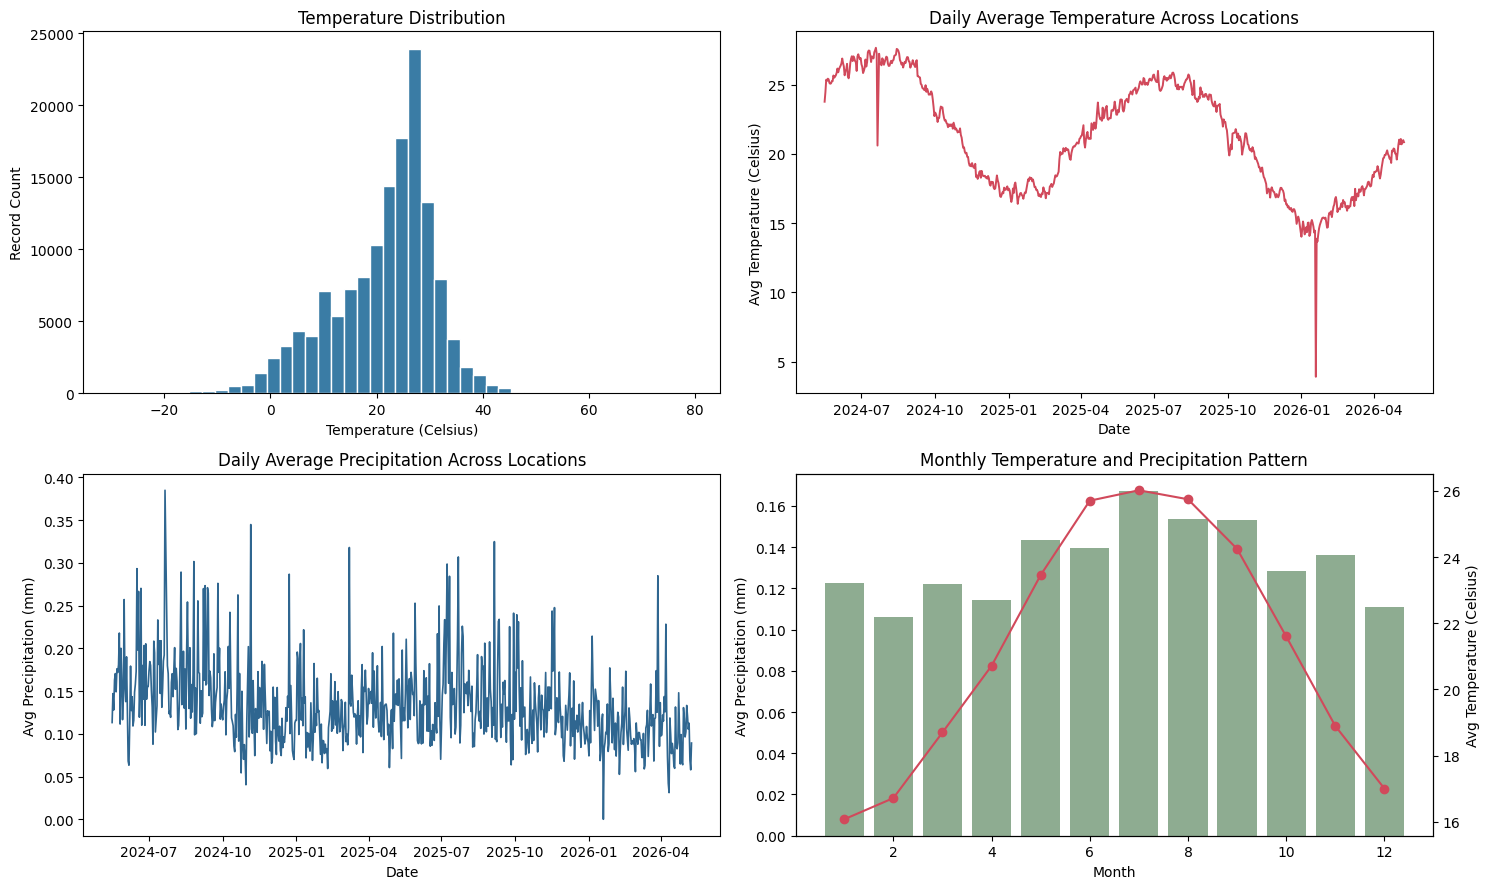

,updated_date,avg_temperature_celsius,median_temperature_celsius,avg_precip_mm,rainy_location_share,avg_pm25,observations
0,2024-05-16,23.767,24.000,0.113,0.378,18.718,378
1,2024-05-17,24.452,25.000,0.147,0.379,17.334,182
2,2024-05-18,25.356,25.700,0.128,0.366,17.375,205
3,2024-05-19,25.270,25.000,0.163,0.412,14.461,194
4,2024-05-20,25.431,26.000,0.171,0.349,19.024,195


,updated_month,avg_temperature_celsius,avg_precip_mm,rainy_location_share
0,1,16.072,0.122,0.315
1,2,16.713,0.106,0.322
2,3,18.697,0.122,0.324
3,4,20.711,0.114,0.321
4,5,23.455,0.143,0.361
5,6,25.705,0.140,0.341
6,7,26.019,0.167,0.355
7,8,25.748,0.154,0.339
8,9,24.249,0.153,0.339
9,10,21.602,0.129,0.337


In [119]:
daily_weather = (
    eda_weather.groupby("updated_date", dropna=False)
    .agg(
        avg_temperature_celsius=(TARGET_COLUMN, "mean"),
        median_temperature_celsius=(TARGET_COLUMN, "median"),
        avg_precip_mm=("precip_mm", "mean"),
        rainy_location_share=("precip_mm", lambda values: (values > 0).mean()),
        avg_pm25=("air_quality_PM2.5", "mean"),
        observations=(TARGET_COLUMN, "size"),
    )
    .reset_index()
)
daily_weather["updated_date"] = pd.to_datetime(daily_weather["updated_date"])

monthly_weather = (
    eda_weather.groupby("updated_month")
    .agg(
        avg_temperature_celsius=(TARGET_COLUMN, "mean"),
        avg_precip_mm=("precip_mm", "mean"),
        rainy_location_share=("precip_mm", lambda values: (values > 0).mean()),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].hist(eda_weather[TARGET_COLUMN], bins=45, color="#3A7CA5", edgecolor="white")
axes[0, 0].set_title("Temperature Distribution")
axes[0, 0].set_xlabel("Temperature (Celsius)")
axes[0, 0].set_ylabel("Record Count")

axes[0, 1].plot(daily_weather["updated_date"], daily_weather["avg_temperature_celsius"], color="#D1495B", linewidth=1.4)
axes[0, 1].set_title("Daily Average Temperature Across Locations")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Avg Temperature (Celsius)")

axes[1, 0].plot(daily_weather["updated_date"], daily_weather["avg_precip_mm"], color="#2F6690", linewidth=1.2)
axes[1, 0].set_title("Daily Average Precipitation Across Locations")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Avg Precipitation (mm)")

axes[1, 1].bar(monthly_weather["updated_month"], monthly_weather["avg_precip_mm"], color="#7A9E7E", alpha=0.85, label="Avg precipitation")
axes_month = axes[1, 1].twinx()
axes_month.plot(monthly_weather["updated_month"], monthly_weather["avg_temperature_celsius"], color="#D1495B", marker="o", label="Avg temperature")
axes[1, 1].set_title("Monthly Temperature and Precipitation Pattern")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Avg Precipitation (mm)")
axes_month.set_ylabel("Avg Temperature (Celsius)")

fig.tight_layout()
plt.show()

display(daily_weather.head())
display(monthly_weather)

## Numeric Feature Associations

Numeric weather, geography, air-quality, time, and parsed astronomy fields are compared with `temperature_celsius` using Pearson and Spearman correlation. Pearson captures linear relationships, while Spearman captures monotonic relationships.

Direct temperature duplicates and target-adjacent fields remain in the table for transparency but are excluded from the association bar chart.

,feature,feature_group,rows_used,missing_percent,pearson_corr,spearman_corr,abs_spearman_corr,modeling_note
0,temperature_fahrenheit,Temperature companions,140337,0.000,1.000,1.000,1.000,same temperature measurement in Fahrenheit; ta...
1,feels_like_celsius,Temperature companions,140337,0.000,0.984,0.978,0.978,target-adjacent comfort metric; useful for int...
2,feels_like_fahrenheit,Temperature companions,140337,0.000,0.984,0.978,0.978,target-adjacent comfort metric; useful for int...
3,pressure_in,"Pressure, precipitation, humidity, cloud, visi...",140337,0.000,-0.289,-0.483,0.483,duplicate unit of another measurement; keep on...
4,pressure_mb,"Pressure, precipitation, humidity, cloud, visi...",140337,0.000,-0.288,-0.482,0.482,candidate explanatory feature
5,sunrise_minutes,Sun and moon,140337,0.000,-0.562,-0.474,0.474,candidate explanatory feature
6,uv_index,"Pressure, precipitation, humidity, cloud, visi...",140337,0.000,0.490,0.460,0.460,candidate explanatory feature
7,daylight_minutes,Sun and moon,140337,0.000,0.454,0.402,0.402,candidate explanatory feature
8,latitude,Location and geography,140337,0.000,-0.387,-0.395,0.395,candidate explanatory feature
9,hour_sin,Time axis and calendar,140337,0.000,-0.296,-0.334,0.334,candidate explanatory feature


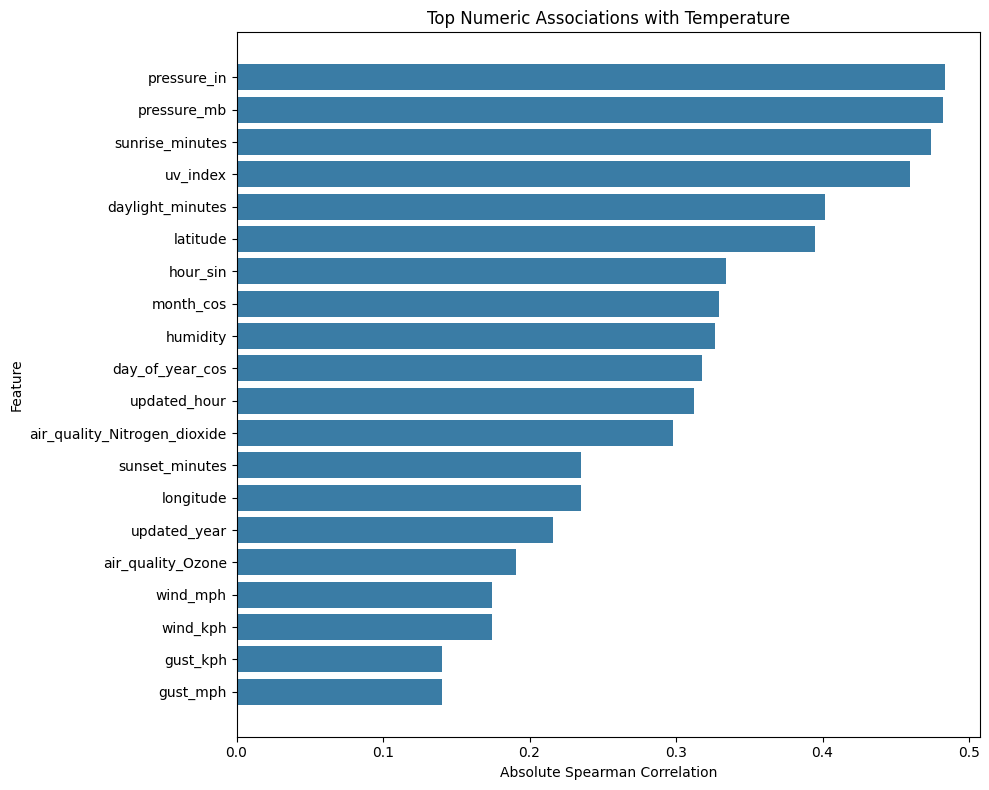

In [120]:
FEATURE_GROUP_BY_COLUMN = {
    row["feature"]: row["feature_group"]
    for row in feature_group_rows
}

DERIVED_FEATURE_GROUPS = {
    "updated_year": "Time axis and calendar",
    "updated_month": "Time axis and calendar",
    "updated_day": "Time axis and calendar",
    "updated_day_of_week": "Time axis and calendar",
    "updated_day_of_year": "Time axis and calendar",
    "updated_week": "Time axis and calendar",
    "updated_quarter": "Time axis and calendar",
    "updated_hour": "Time axis and calendar",
    "updated_is_weekend": "Time axis and calendar",
    "month_sin": "Time axis and calendar",
    "month_cos": "Time axis and calendar",
    "day_of_year_sin": "Time axis and calendar",
    "day_of_year_cos": "Time axis and calendar",
    "hour_sin": "Time axis and calendar",
    "hour_cos": "Time axis and calendar",
    "sunrise_minutes": "Sun and moon",
    "sunset_minutes": "Sun and moon",
    "moonrise_minutes": "Sun and moon",
    "moonset_minutes": "Sun and moon",
    "daylight_minutes": "Sun and moon",
}
FEATURE_GROUP_BY_COLUMN.update(DERIVED_FEATURE_GROUPS)


def numeric_feature_group(feature):
    return FEATURE_GROUP_BY_COLUMN.get(feature, "Derived or supporting numeric")


def modeling_note(feature):
    if feature == TARGET_COLUMN:
        return "target"
    if feature == "temperature_fahrenheit":
        return "same temperature measurement in Fahrenheit; table coverage only"
    if feature in ["feels_like_celsius", "feels_like_fahrenheit"]:
        return "target-adjacent comfort metric; useful for interpretation, risky as a predictor"
    if feature in ["pressure_in", "precip_in", "visibility_miles", "wind_kph", "gust_kph"]:
        return "duplicate unit of another measurement; keep one unit during modeling"
    if feature == "last_updated_epoch":
        return "raw time proxy; parsed calendar fields are more interpretable"
    return "candidate explanatory feature"


def numeric_temperature_association(frame, columns, target=TARGET_COLUMN):
    rows = []
    for col in columns:
        if col == target or col not in frame.columns:
            continue
        pair = frame[[col, target]].apply(pd.to_numeric, errors="coerce").dropna()
        rows.append({
            "feature": col,
            "feature_group": numeric_feature_group(col),
            "rows_used": len(pair),
            "missing_percent": frame[col].isna().mean() * 100,
            "pearson_corr": pair[col].corr(pair[target], method="pearson") if len(pair) > 1 else np.nan,
            "spearman_corr": pair[col].corr(pair[target], method="spearman") if len(pair) > 1 else np.nan,
            "abs_spearman_corr": abs(pair[col].corr(pair[target], method="spearman")) if len(pair) > 1 else np.nan,
            "modeling_note": modeling_note(col),
        })
    return pd.DataFrame(rows).sort_values("abs_spearman_corr", ascending=False).reset_index(drop=True)


original_numeric_features = [
    col for col in weather_raw.select_dtypes(include=np.number).columns
    if col in eda_weather.columns and col != TARGET_COLUMN
]
derived_numeric_features = [
    col for col in DERIVED_FEATURE_GROUPS
    if col in eda_weather.columns
]

numeric_association_features = list(dict.fromkeys(original_numeric_features + derived_numeric_features))
numeric_assoc = numeric_temperature_association(eda_weather, numeric_association_features)

display(numeric_assoc)

excluded_visual_features = {
    "temperature_fahrenheit",
    "feels_like_celsius",
    "feels_like_fahrenheit",
    "last_updated_epoch",
}
plot_numeric_assoc = (
    numeric_assoc
    .loc[~numeric_assoc["feature"].isin(excluded_visual_features)]
    .dropna(subset=["abs_spearman_corr"])
    .head(20)
    .sort_values("abs_spearman_corr")
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_numeric_assoc["feature"], plot_numeric_assoc["abs_spearman_corr"], color="#3A7CA5")
ax.set_title("Top Numeric Associations with Temperature")
ax.set_xlabel("Absolute Spearman Correlation")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## Categorical Feature Associations

This section covers categorical fields: country, city, timezone, weather condition, wind direction, and moon phase. Raw sunrise/sunset/moonrise/moonset are not treated as categories because thousands of clock-string categories are hard to interpret; instead, they are represented above as parsed minute fields.

For categorical-vs-temperature association, the correlation ratio, also called eta, measures how much average temperature differs across categories.

,feature,feature_group,unique_values,rows_used,missing_percent,correlation_ratio_eta
0,location_name,Location and geography,257,140337,0.000,0.719
1,timezone,Location and geography,199,140337,0.000,0.715
2,country,Location and geography,211,140337,0.000,0.714
3,condition_text_standardized,Categorical feature,48,140337,0.000,0.361
4,wind_direction,Weather condition and wind,16,140337,0.000,0.081
5,moon_phase,Sun and moon,8,140337,0.000,0.018


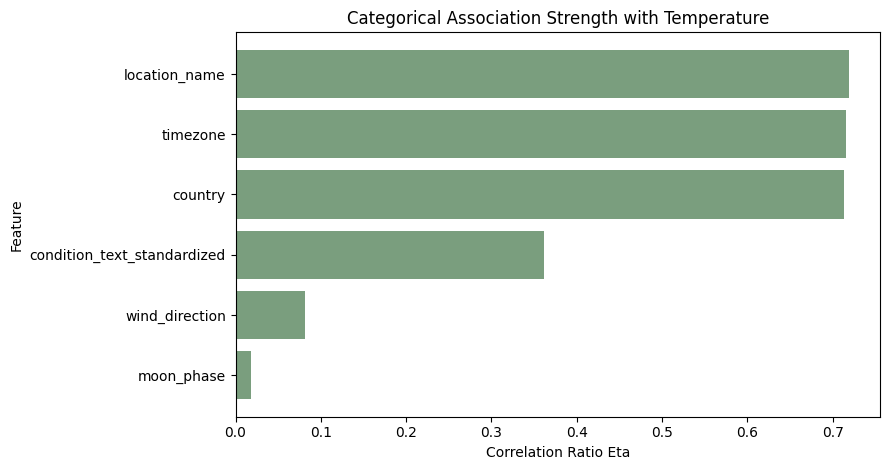

Top weather-condition categories by record count:


,condition_text_standardized,records,avg_temperature_celsius,median_temperature_celsius,avg_precip_mm,avg_pm25
0,Partly Cloudy,49157,22.025,24.300,0.113,19.115
1,Sunny,40393,23.117,24.400,0.002,32.339
2,Patchy Rain Nearby,11730,23.475,25.300,0.156,16.148
3,Overcast,7628,17.041,18.500,0.152,21.245
4,Clear,7491,17.274,19.400,0.007,25.263
5,Mist,5875,17.894,20.800,0.032,44.520
6,Light Rain,4379,16.712,16.200,0.585,15.641
7,Light Rain Shower,3200,23.859,25.400,0.756,14.240
8,Fog,1747,14.611,17.800,0.021,19.044
9,Cloudy,1688,18.823,21.250,0.000,19.712


Top countries by record count:


,country,records,avg_temperature_celsius,median_temperature_celsius,avg_precip_mm,avg_pm25
0,Bulgaria,1660,14.404,12.400,0.100,18.608
1,Indonesia,1443,28.282,28.800,0.484,84.025
2,Thailand,1441,31.130,31.200,0.209,28.951
3,Turkey,1438,16.590,15.100,0.063,24.497
4,Sudan,1438,29.775,29.600,0.016,45.650
5,Bolivia,1431,17.260,16.600,0.114,12.339
6,Iran,1398,19.140,19.200,0.032,38.701
7,Belgium,1351,12.326,12.100,0.085,17.620
8,Madagascar,1179,25.701,25.200,0.061,6.615
9,Vietnam,1174,26.982,27.300,0.270,59.111


Top timezones by record count:


,timezone,records,avg_temperature_celsius,median_temperature_celsius,avg_precip_mm,avg_pm25
0,Asia/Bangkok,2573,29.273,30.100,0.241,42.899
1,Europe/Sofia,1624,14.143,12.150,0.097,18.914
2,Europe/Rome,1498,18.872,18.100,0.087,17.410
3,America/La_Paz,1456,17.347,16.850,0.112,12.233
4,Asia/Jakarta,1443,28.282,28.800,0.484,84.025
5,Europe/Istanbul,1440,16.611,15.150,0.063,24.473
6,Africa/Khartoum,1438,29.775,29.600,0.016,45.650
7,Asia/Tehran,1398,19.140,19.200,0.032,38.701
8,Europe/Brussels,1352,12.329,12.100,0.085,17.608
9,Indian/Antananarivo,1179,25.701,25.200,0.061,6.615


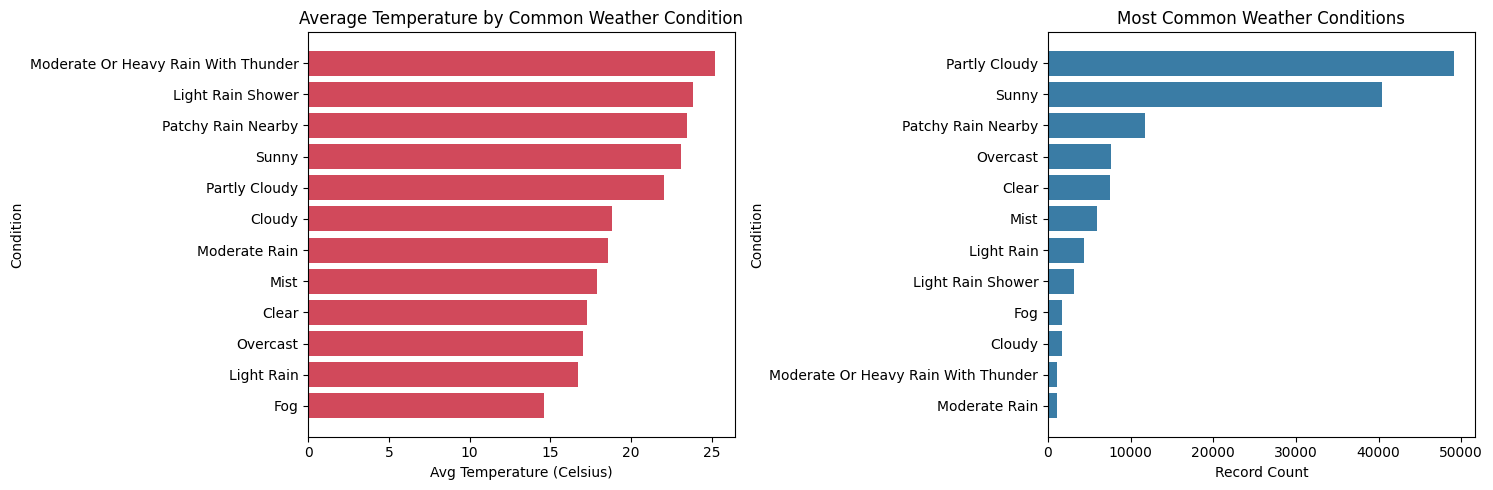

In [121]:
def correlation_ratio(categories, values):
    frame = pd.DataFrame({"category": categories, "value": values}).dropna()
    if frame.empty or frame["category"].nunique() <= 1 or frame["value"].nunique() <= 1:
        return np.nan

    codes, _ = pd.factorize(frame["category"])
    grand_mean = frame["value"].mean()
    ss_between = 0.0

    for code_value in np.unique(codes):
        group = frame.loc[codes == code_value, "value"]
        ss_between += len(group) * (group.mean() - grand_mean) ** 2

    ss_total = ((frame["value"] - grand_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total != 0 else np.nan


def categorical_temperature_association(frame, columns, target=TARGET_COLUMN):
    rows = []
    for col in columns:
        if col not in frame.columns:
            continue
        cleaned_category = clean_category(frame[col])
        target_values = pd.to_numeric(frame[target], errors="coerce")
        rows.append({
            "feature": col,
            "feature_group": FEATURE_GROUP_BY_COLUMN.get(col, "Categorical feature"),
            "unique_values": cleaned_category.nunique(dropna=True),
            "rows_used": target_values.notna().sum(),
            "missing_percent": frame[col].isna().mean() * 100,
            "correlation_ratio_eta": correlation_ratio(cleaned_category, target_values),
        })
    return pd.DataFrame(rows).sort_values("correlation_ratio_eta", ascending=False).reset_index(drop=True)


def category_target_summary(frame, feature, target=TARGET_COLUMN, min_count=250, top_n=15):
    summary = (
        frame.assign(_category=clean_category(frame[feature]))
        .groupby("_category", dropna=False)
        .agg(
            records=(target, "size"),
            avg_temperature_celsius=(target, "mean"),
            median_temperature_celsius=(target, "median"),
            avg_precip_mm=("precip_mm", "mean"),
            avg_pm25=("air_quality_PM2.5", "mean"),
        )
        .query("records >= @min_count")
        .sort_values("records", ascending=False)
        .head(top_n)
        .reset_index()
        .rename(columns={"_category": feature})
    )
    return summary


categorical_features = [
    "country",
    "location_name",
    "timezone",
    "condition_text_standardized",
    "wind_direction",
    "moon_phase",
]

categorical_assoc = categorical_temperature_association(eda_weather, categorical_features)
display(categorical_assoc)

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_categorical_assoc = categorical_assoc.sort_values("correlation_ratio_eta")
ax.barh(plot_categorical_assoc["feature"], plot_categorical_assoc["correlation_ratio_eta"], color="#7A9E7E")
ax.set_title("Categorical Association Strength with Temperature")
ax.set_xlabel("Correlation Ratio Eta")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

condition_summary = category_target_summary(
    eda_weather,
    "condition_text_standardized",
    min_count=500,
    top_n=12,
)
country_summary = category_target_summary(
    eda_weather,
    "country",
    min_count=500,
    top_n=12,
)
timezone_summary = category_target_summary(
    eda_weather,
    "timezone",
    min_count=500,
    top_n=12,
)

print("Top weather-condition categories by record count:")
display(condition_summary)
print("Top countries by record count:")
display(country_summary)
print("Top timezones by record count:")
display(timezone_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
condition_plot = condition_summary.sort_values("avg_temperature_celsius")
axes[0].barh(condition_plot["condition_text_standardized"], condition_plot["avg_temperature_celsius"], color="#D1495B")
axes[0].set_title("Average Temperature by Common Weather Condition")
axes[0].set_xlabel("Avg Temperature (Celsius)")
axes[0].set_ylabel("Condition")

condition_count_plot = condition_summary.sort_values("records")
axes[1].barh(condition_count_plot["condition_text_standardized"], condition_count_plot["records"], color="#3A7CA5")
axes[1].set_title("Most Common Weather Conditions")
axes[1].set_xlabel("Record Count")
axes[1].set_ylabel("Condition")

plt.tight_layout()
plt.show()

## Core Weather Relationships

This section focuses on physical weather measurements: wind, gust, pressure, precipitation, humidity, cloud, visibility, and UV. These variables are the main non-temperature weather signals used to explain temperature patterns.

,feature,feature_group,rows_used,missing_percent,pearson_corr,spearman_corr,abs_spearman_corr,modeling_note
4,pressure_mb,"Pressure, precipitation, humidity, cloud, visi...",140337,0.000,-0.288,-0.482,0.482,candidate explanatory feature
6,uv_index,"Pressure, precipitation, humidity, cloud, visi...",140337,0.000,0.490,0.460,0.460,candidate explanatory feature
11,humidity,"Pressure, precipitation, humidity, cloud, visi...",140337,0.000,-0.339,-0.326,0.326,candidate explanatory feature
20,wind_mph,Weather condition and wind,140337,0.000,0.091,0.175,0.175,candidate explanatory feature
23,gust_mph,Weather condition and wind,140337,0.000,0.077,0.140,0.140,candidate explanatory feature
27,cloud,"Pressure, precipitation, humidity, cloud, visi...",140337,0.000,-0.130,-0.099,0.099,candidate explanatory feature
32,visibility_km,"Pressure, precipitation, humidity, cloud, visi...",140337,0.000,0.110,0.075,0.075,candidate explanatory feature
39,precip_mm,"Pressure, precipitation, humidity, cloud, visi...",140337,0.000,0.034,0.053,0.053,candidate explanatory feature
43,wind_degree,Weather condition and wind,140337,0.000,-0.024,-0.016,0.016,candidate explanatory feature


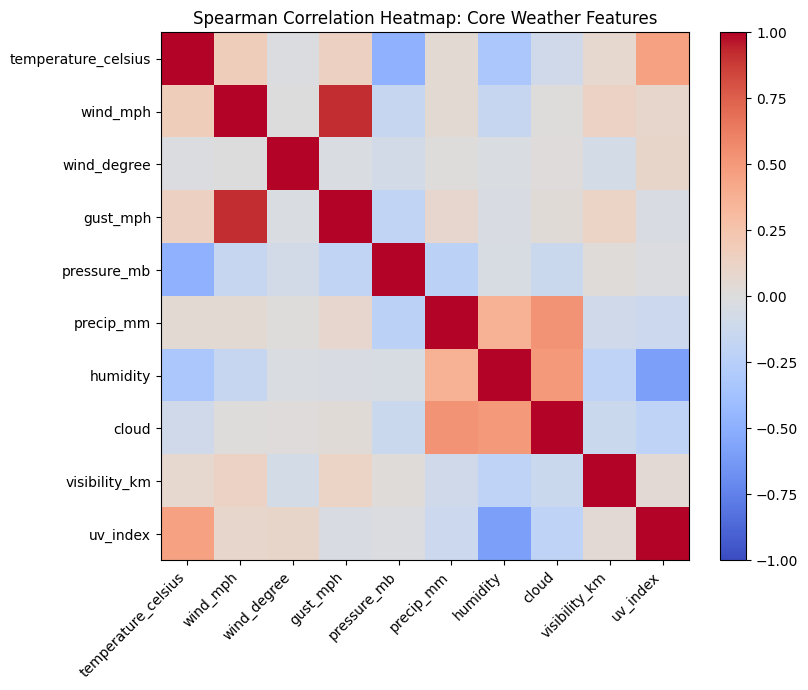

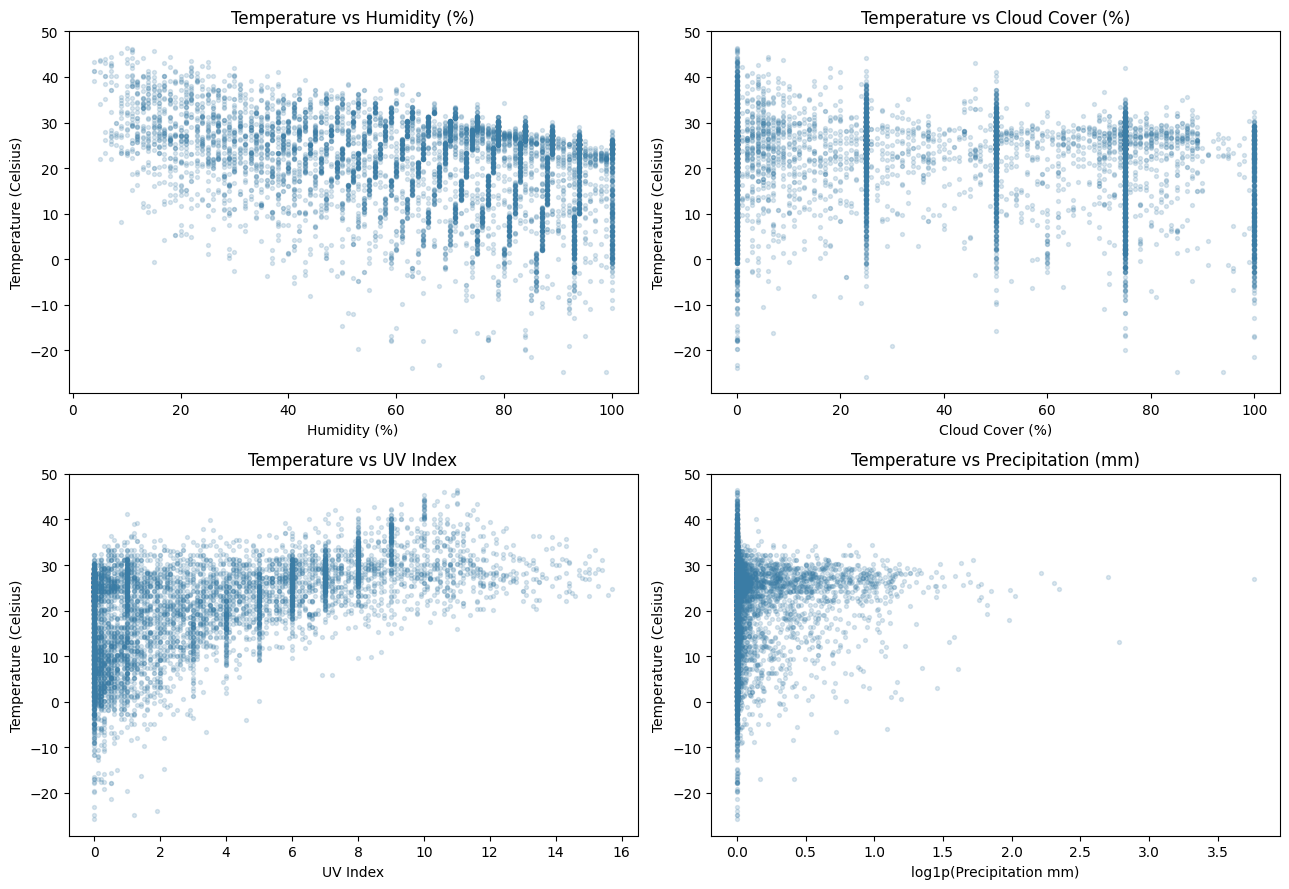

In [122]:
core_weather_features = [
    "wind_mph",
    "wind_degree",
    "gust_mph",
    "pressure_mb",
    "precip_mm",
    "humidity",
    "cloud",
    "visibility_km",
    "uv_index",
]

core_weather_assoc = numeric_assoc.loc[numeric_assoc["feature"].isin(core_weather_features)].copy()
display(core_weather_assoc.sort_values("abs_spearman_corr", ascending=False))

corr_features = [TARGET_COLUMN] + core_weather_features
core_corr = eda_weather[corr_features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(core_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=45, ha="right")
ax.set_yticks(range(len(corr_features)))
ax.set_yticklabels(corr_features)
ax.set_title("Spearman Correlation Heatmap: Core Weather Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

sample_weather = eda_weather.sample(min(8_000, len(eda_weather)), random_state=RANDOM_STATE)
scatter_specs = [
    ("humidity", "Humidity (%)"),
    ("cloud", "Cloud Cover (%)"),
    ("uv_index", "UV Index"),
    ("precip_mm", "Precipitation (mm)"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (feature, label) in zip(axes.ravel(), scatter_specs):
    x = np.log1p(sample_weather[feature]) if feature == "precip_mm" else sample_weather[feature]
    xlabel = "log1p(Precipitation mm)" if feature == "precip_mm" else label
    ax.scatter(x, sample_weather[TARGET_COLUMN], s=8, alpha=0.18, color="#3A7CA5")
    ax.set_title(f"Temperature vs {label}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Temperature (Celsius)")

plt.tight_layout()
plt.show()

## Air Quality and Environmental Impact

Pollutant-level measurements are compared with temperature and core weather variables to evaluate environmental relationships in the dataset.

,feature,feature_group,rows_used,missing_percent,pearson_corr,spearman_corr,abs_spearman_corr,modeling_note
14,air_quality_Nitrogen_dioxide,Air quality,140337,0.000,-0.137,-0.298,0.298,candidate explanatory feature
19,air_quality_Ozone,Air quality,140337,0.000,0.246,0.191,0.191,candidate explanatory feature
24,air_quality_PM10,Air quality,140337,0.000,0.109,0.131,0.131,candidate explanatory feature
25,air_quality_Sulphur_dioxide,Air quality,140337,0.000,-0.033,-0.116,0.116,candidate explanatory feature
28,air_quality_us-epa-index,Air quality,140337,0.000,0.090,0.091,0.091,candidate explanatory feature
29,air_quality_gb-defra-index,Air quality,140337,0.000,0.093,0.087,0.087,candidate explanatory feature
35,air_quality_PM2.5,Air quality,140337,0.000,0.059,0.073,0.073,candidate explanatory feature
42,air_quality_Carbon_Monoxide,Air quality,140337,0.000,0.001,0.026,0.026,candidate explanatory feature


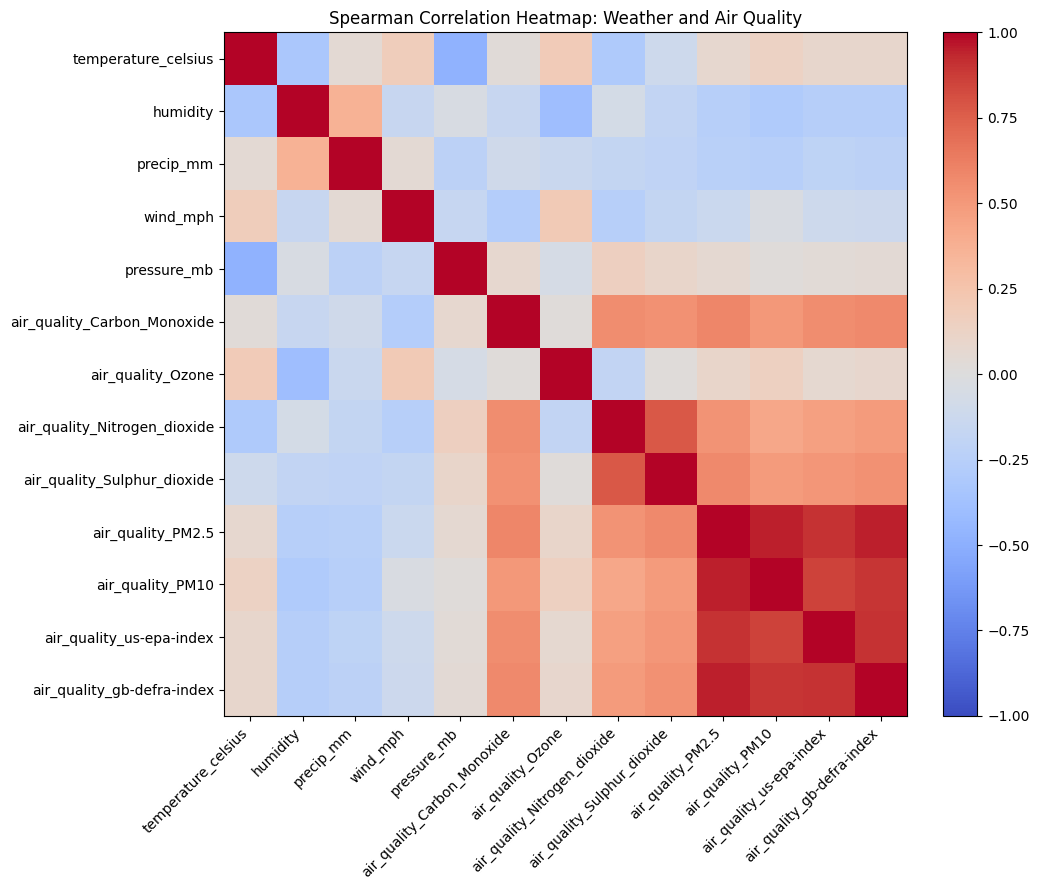

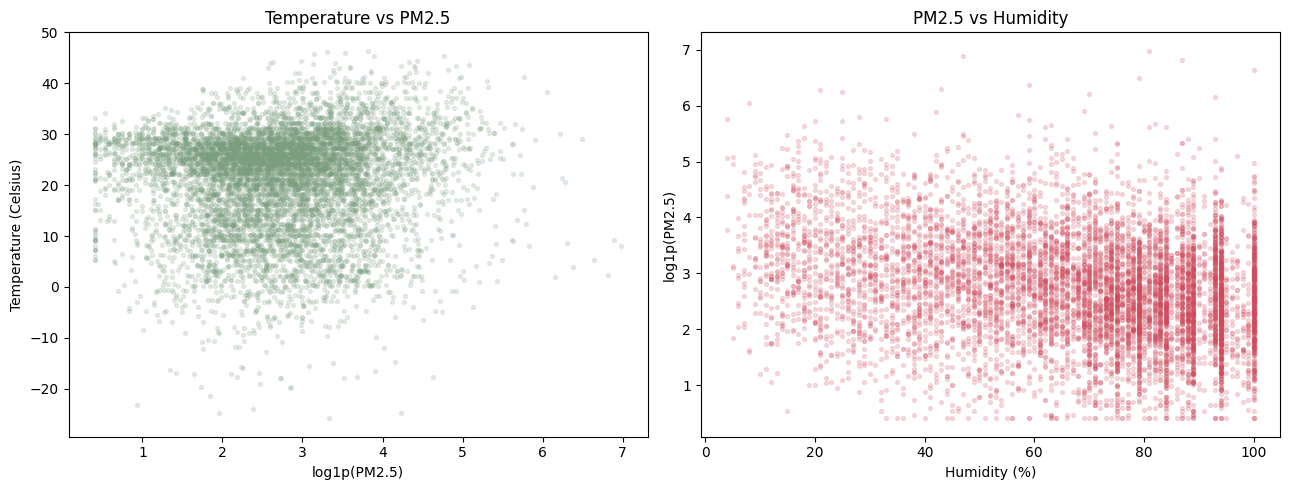

In [123]:
air_quality_features = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_us-epa-index",
    "air_quality_gb-defra-index",
]

air_quality_assoc = numeric_assoc.loc[numeric_assoc["feature"].isin(air_quality_features)].copy()
display(air_quality_assoc.sort_values("abs_spearman_corr", ascending=False))

air_quality_corr_features = [
    TARGET_COLUMN,
    "humidity",
    "precip_mm",
    "wind_mph",
    "pressure_mb",
] + air_quality_features

air_quality_corr = eda_weather[air_quality_corr_features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(air_quality_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(air_quality_corr_features)))
ax.set_xticklabels(air_quality_corr_features, rotation=45, ha="right")
ax.set_yticks(range(len(air_quality_corr_features)))
ax.set_yticklabels(air_quality_corr_features)
ax.set_title("Spearman Correlation Heatmap: Weather and Air Quality")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

sample_air = eda_weather.sample(min(8_000, len(eda_weather)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(np.log1p(sample_air["air_quality_PM2.5"]), sample_air[TARGET_COLUMN], s=8, alpha=0.18, color="#7A9E7E")
axes[0].set_title("Temperature vs PM2.5")
axes[0].set_xlabel("log1p(PM2.5)")
axes[0].set_ylabel("Temperature (Celsius)")

axes[1].scatter(sample_air["humidity"], np.log1p(sample_air["air_quality_PM2.5"]), s=8, alpha=0.18, color="#D1495B")
axes[1].set_title("PM2.5 vs Humidity")
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("log1p(PM2.5)")

plt.tight_layout()
plt.show()

## Time, Seasonality, and Climate Patterns

Month, hour, and day-of-week patterns show recurring time effects that influence climate trends and forecasting features.

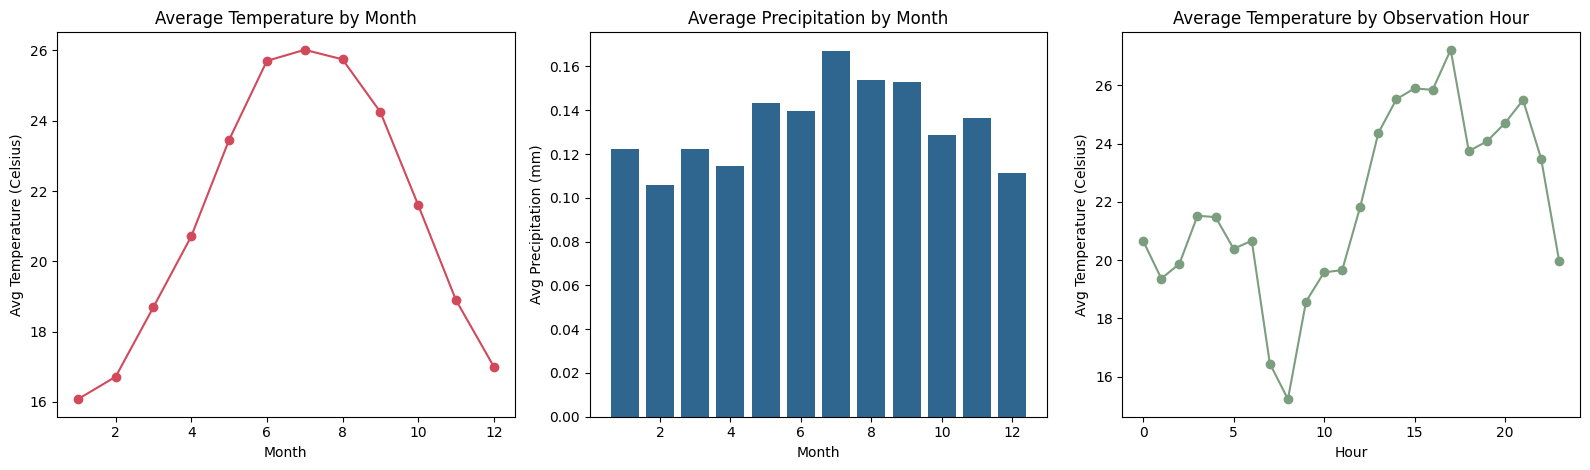

,updated_month,avg_temperature_celsius,median_temperature_celsius,avg_precip_mm,avg_pm25,observations
0,1,16.072,19.800,0.122,28.428,11845
1,2,16.713,20.200,0.106,27.564,10915
2,3,18.697,20.900,0.122,25.912,11908
3,4,20.711,22.100,0.114,23.198,11700
4,5,23.455,24.200,0.143,23.322,11079
5,6,25.705,26.300,0.140,22.111,11653
6,7,26.019,26.300,0.167,21.114,11623
7,8,25.748,26.300,0.154,20.530,12089
8,9,24.249,25.200,0.153,23.026,11703
9,10,21.602,23.850,0.129,20.527,12064


,updated_hour,avg_temperature_celsius,avg_precip_mm,observations
0,0,20.654,0.178,1166
1,1,19.367,0.118,1755
2,2,19.875,0.111,3810
3,3,21.524,0.123,3872
4,4,21.477,0.123,4548
5,5,20.389,0.132,4148
6,6,20.666,0.100,3853
7,7,16.453,0.097,5656
8,8,15.226,0.134,11096
9,9,18.576,0.102,11698


,updated_day_of_week,avg_temperature_celsius,avg_precip_mm,observations
0,0,21.256,0.135,19586
1,1,21.243,0.133,19993
2,2,21.248,0.130,20066
3,3,21.311,0.130,20433
4,4,21.258,0.137,20223
5,5,21.246,0.136,20231
6,6,21.140,0.132,19805


In [124]:
month_profile = (
    eda_weather.groupby("updated_month")
    .agg(
        avg_temperature_celsius=(TARGET_COLUMN, "mean"),
        median_temperature_celsius=(TARGET_COLUMN, "median"),
        avg_precip_mm=("precip_mm", "mean"),
        avg_pm25=("air_quality_PM2.5", "mean"),
        observations=(TARGET_COLUMN, "size"),
    )
    .reset_index()
)

hour_profile = (
    eda_weather.groupby("updated_hour")
    .agg(
        avg_temperature_celsius=(TARGET_COLUMN, "mean"),
        avg_precip_mm=("precip_mm", "mean"),
        observations=(TARGET_COLUMN, "size"),
    )
    .reset_index()
)

day_profile = (
    eda_weather.groupby("updated_day_of_week")
    .agg(
        avg_temperature_celsius=(TARGET_COLUMN, "mean"),
        avg_precip_mm=("precip_mm", "mean"),
        observations=(TARGET_COLUMN, "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(month_profile["updated_month"], month_profile["avg_temperature_celsius"], marker="o", color="#D1495B")
axes[0].set_title("Average Temperature by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Temperature (Celsius)")

axes[1].bar(month_profile["updated_month"], month_profile["avg_precip_mm"], color="#2F6690")
axes[1].set_title("Average Precipitation by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Precipitation (mm)")

axes[2].plot(hour_profile["updated_hour"], hour_profile["avg_temperature_celsius"], marker="o", color="#7A9E7E")
axes[2].set_title("Average Temperature by Observation Hour")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Avg Temperature (Celsius)")

plt.tight_layout()
plt.show()

display(month_profile)
display(hour_profile.head(24))
display(day_profile)

## Spatial and Geographical Patterns

Country and location summaries, latitude bands, and a latitude-longitude scatter view highlight geographic variation in weather conditions.

Countries with the most observations:


,records,avg_temperature_celsius,median_temperature_celsius,avg_precip_mm,avg_pm25,min_latitude,max_latitude
country,,,,,,,
Bulgaria,1660,14.404,12.400,0.100,18.608,42.680,43.814
Indonesia,1443,28.282,28.800,0.484,84.025,-8.183,-0.140
Thailand,1441,31.130,31.200,0.209,28.951,13.750,18.783
Sudan,1438,29.775,29.600,0.016,45.650,12.150,15.590
Turkey,1438,16.590,15.100,0.063,24.497,39.550,39.930
Bolivia,1431,17.260,16.600,0.114,12.339,-19.043,-11.180
Iran,1398,19.140,19.200,0.032,38.701,35.726,36.263
Belgium,1351,12.326,12.100,0.085,17.620,50.600,51.250
Madagascar,1179,25.701,25.200,0.061,6.615,-24.370,-18.917


Hottest countries among countries with at least 300 records:


,records,avg_temperature_celsius,median_temperature_celsius,avg_precip_mm,avg_pm25,min_latitude,max_latitude
country,,,,,,,
United Arab Emirates,721,32.102,32.900,0.000,57.126,24.467,24.470
Qatar,719,32.071,33.100,0.001,56.583,25.287,25.290
Cambodia,720,31.798,31.800,0.142,28.037,11.550,11.550
Oman,721,31.489,32.000,0.004,35.735,23.610,23.613
Djibouti,719,31.294,30.500,0.025,28.389,11.595,11.600
Thailand,1441,31.130,31.200,0.209,28.951,13.750,18.783
Bangladesh,720,30.989,31.100,0.297,70.471,23.720,23.723
Myanmar,721,30.933,31.100,0.401,28.428,16.780,16.783
Kuwait,720,30.682,30.150,0.010,91.392,29.367,29.370


Coolest countries among countries with at least 300 records:


,records,avg_temperature_celsius,median_temperature_celsius,avg_precip_mm,avg_pm25,min_latitude,max_latitude
country,,,,,,,
Mongolia,720,3.712,6.000,0.037,22.552,47.917,47.920
Canada,719,4.825,5.400,0.146,8.828,45.417,45.420
Iceland,719,5.450,6.000,0.177,3.899,63.365,64.150
Norway,719,7.821,8.200,0.103,10.153,59.917,59.920
Kazakhstan,720,8.276,10.100,0.062,11.970,51.180,51.181
Russia,775,8.331,7.300,0.082,40.479,51.700,59.890
Finland,721,8.512,8.100,0.077,7.356,60.176,60.180
United States of America,713,8.625,8.900,0.050,6.107,40.710,48.080
Andorra,721,8.687,7.600,0.123,4.726,42.500,42.500


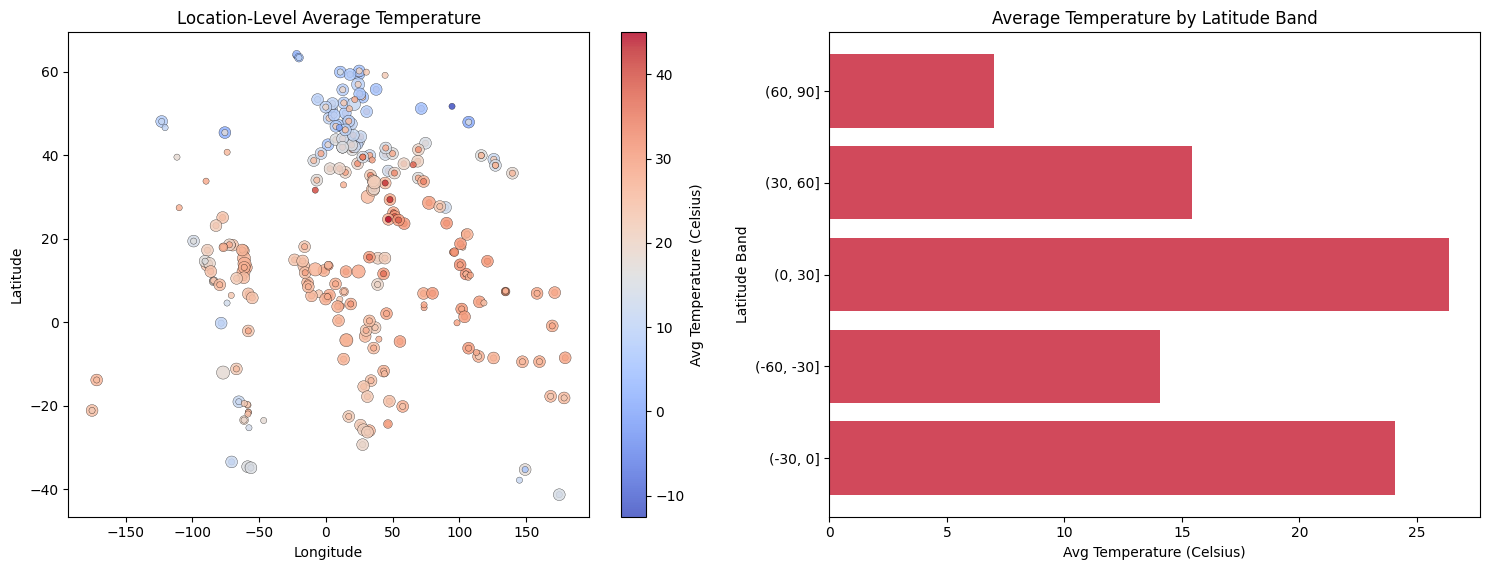

,country,location_name,latitude,longitude,records,avg_temperature_celsius,avg_precip_mm,avg_pm25
347,Saudi Arabien,Ar Riyadh,24.640,46.770,1,45.000,0.000,22.300
207,Kuwait,Kuwait,29.370,47.980,1,44.400,0.000,176.700
183,Iraq,Baghdad,33.340,44.390,139,42.656,0.000,22.416
209,Kuwait,Kuwait City,29.370,47.960,138,42.265,0.000,51.291
345,Saudi Arabia,Riyadh,24.640,46.770,138,42.178,0.000,31.961
246,Marrocos,Morocco City,31.630,-8.000,1,40.300,0.000,8.200
324,Qatar,Doha,25.290,51.530,139,38.917,0.000,50.113
412,Turkménistan,Krasnyy Turkmenistan,37.700,65.370,1,37.800,0.000,6.700
423,United Arab Emirates,Abu Dhabi,24.470,54.370,139,37.601,0.000,53.010
26,Bahrain,Manama,26.240,50.580,139,36.910,0.000,54.707


In [125]:
country_geo_summary = (
    eda_weather.groupby("country")
    .agg(
        records=(TARGET_COLUMN, "size"),
        avg_temperature_celsius=(TARGET_COLUMN, "mean"),
        median_temperature_celsius=(TARGET_COLUMN, "median"),
        avg_precip_mm=("precip_mm", "mean"),
        avg_pm25=("air_quality_PM2.5", "mean"),
        min_latitude=("latitude", "min"),
        max_latitude=("latitude", "max"),
    )
    .sort_values("records", ascending=False)
)

location_geo_summary = (
    eda_weather.groupby(["country", "location_name", "latitude", "longitude"], dropna=False)
    .agg(
        records=(TARGET_COLUMN, "size"),
        avg_temperature_celsius=(TARGET_COLUMN, "mean"),
        avg_precip_mm=("precip_mm", "mean"),
        avg_pm25=("air_quality_PM2.5", "mean"),
    )
    .reset_index()
)

print("Countries with the most observations:")
display(country_geo_summary.head(15))
print("Hottest countries among countries with at least 300 records:")
display(country_geo_summary.query("records >= 300").sort_values("avg_temperature_celsius", ascending=False).head(12))
print("Coolest countries among countries with at least 300 records:")
display(country_geo_summary.query("records >= 300").sort_values("avg_temperature_celsius").head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
scatter = axes[0].scatter(
    location_geo_summary["longitude"],
    location_geo_summary["latitude"],
    c=location_geo_summary["avg_temperature_celsius"],
    s=np.clip(location_geo_summary["records"] / 8, 20, 100),
    cmap="coolwarm",
    alpha=0.82,
    edgecolor="black",
    linewidth=0.25,
)
axes[0].set_title("Location-Level Average Temperature")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(scatter, ax=axes[0], label="Avg Temperature (Celsius)")

latitude_bins = pd.cut(eda_weather["latitude"], bins=[-90, -60, -30, 0, 30, 60, 90])
latitude_summary = (
    eda_weather.assign(latitude_band=latitude_bins.astype(str))
    .groupby("latitude_band", observed=False)
    .agg(
        avg_temperature_celsius=(TARGET_COLUMN, "mean"),
        avg_precip_mm=("precip_mm", "mean"),
        records=(TARGET_COLUMN, "size"),
    )
    .reset_index()
)

axes[1].barh(latitude_summary["latitude_band"], latitude_summary["avg_temperature_celsius"], color="#D1495B")
axes[1].set_title("Average Temperature by Latitude Band")
axes[1].set_xlabel("Avg Temperature (Celsius)")
axes[1].set_ylabel("Latitude Band")

plt.tight_layout()
plt.show()

display(location_geo_summary.sort_values("avg_temperature_celsius", ascending=False).head(12))

## Statistical Anomaly Detection

Interpretable statistical flags are created using global IQR bounds for selected weather and air-quality measures, plus location-relative temperature z-scores. Location-relative scoring avoids treating normal regional climate differences as anomalies.

,feature,lower_iqr_bound,upper_iqr_bound,anomaly_count,anomaly_percent
1,precip_mm,-0.030,0.050,28455,20.276
7,air_quality_PM10,-36.855,87.825,14959,10.659
6,air_quality_PM2.5,-23.750,58.330,11543,8.225
4,pressure_mb,998.000,"1,030.000",4141,2.951
3,gust_mph,-6.750,28.050,3735,2.661
8,air_quality_Ozone,-15.550,127.250,3586,2.555
2,wind_mph,-7.000,21.800,2227,1.587
0,temperature_celsius,-3.000,46.600,1989,1.417
5,humidity,-1.500,138.500,0,0.000


,country,location_name,last_updated,temperature_celsius,temperature_location_zscore,condition_text_standardized,humidity,precip_mm,air_quality_PM2.5,abs_z
42816,Fiji Islands,Suva,2026-04-24 18:30:00,79.300,18.067,Partly Cloudy,7,0.990,4.250,18.067
37079,Ecuador,Quito,2024-05-17 11:00:00,18.900,5.661,Patchy Rain Nearby,55,0.280,42.200,5.661
15790,Bolivia,Sucre,2024-07-04 09:00:00,-0.900,-5.640,Sunny,37,0.000,3.000,5.640
35670,Dominica,Roseau,2024-06-12 10:15:00,35.300,4.904,Partly Cloudy,50,0.000,1.400,4.904
95865,Paraguay,Aguaray,2025-08-26 05:15:00,8.800,-4.727,Fog,97,0.000,17.621,4.727
104620,Samoa,Apia,2024-07-20 01:30:00,19.400,-4.529,Partly Cloudy,100,0.010,2.200,4.529
117520,Suriname,Paramaribo,2024-05-22 11:15:00,32.000,4.517,Partly Cloudy,67,0.490,1.500,4.517
103701,Saint Lucia,Castries,2025-12-25 03:00:00,20.300,-4.502,Partly Cloudy,100,0.000,4.450,4.502
61830,Jamaica,Norman Gardens,2024-05-16 03:45:00,21.900,-4.457,Patchy Rain Nearby,84,0.100,10.100,4.457
37096,Ecuador,Quito,2024-06-03 09:15:00,17.100,4.447,Sunny,44,0.000,15.800,4.447


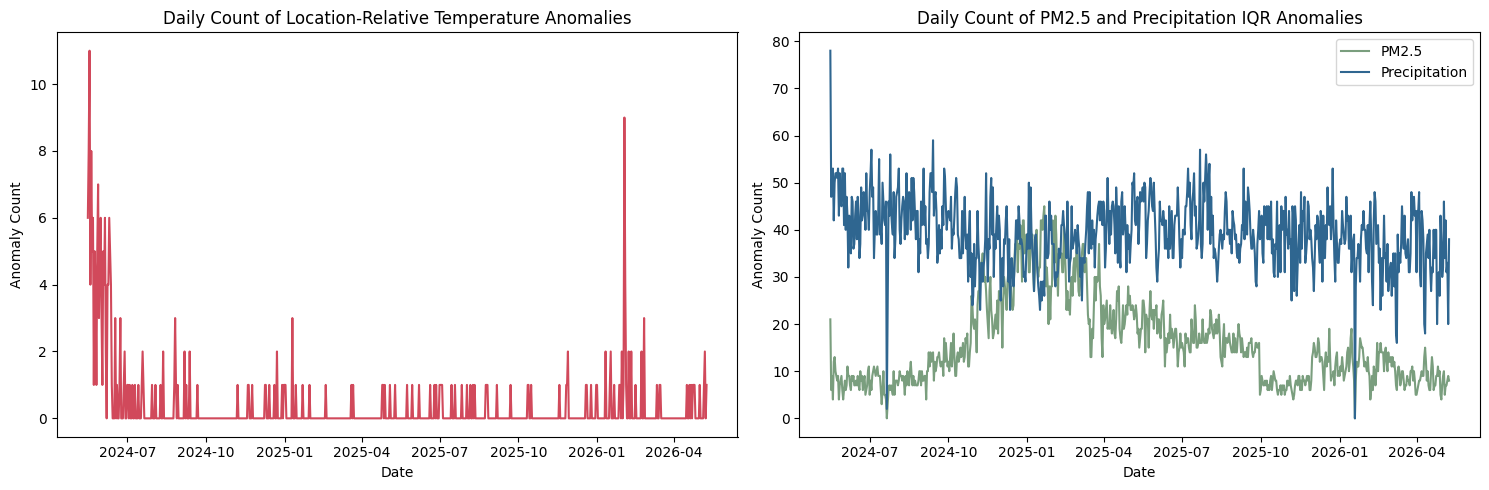

In [126]:
anomaly_features = [
    TARGET_COLUMN,
    "precip_mm",
    "wind_mph",
    "gust_mph",
    "pressure_mb",
    "humidity",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Ozone",
]

anomaly_frame = eda_weather.copy()
anomaly_rows = []

for feature in anomaly_features:
    lower, upper = iqr_bounds(anomaly_frame[feature], multiplier=1.5)
    flag_col = f"{feature}_iqr_anomaly"
    anomaly_frame[flag_col] = anomaly_frame[feature].lt(lower) | anomaly_frame[feature].gt(upper)
    anomaly_rows.append({
        "feature": feature,
        "lower_iqr_bound": lower,
        "upper_iqr_bound": upper,
        "anomaly_count": int(anomaly_frame[flag_col].sum()),
        "anomaly_percent": anomaly_frame[flag_col].mean() * 100,
    })

location_temperature = anomaly_frame.groupby("location_key")[TARGET_COLUMN]
location_temperature_mean = location_temperature.transform("mean")
location_temperature_std = location_temperature.transform("std").replace(0, np.nan)
anomaly_frame["temperature_location_zscore"] = (
    anomaly_frame[TARGET_COLUMN] - location_temperature_mean
) / location_temperature_std
anomaly_frame["temperature_location_z_anomaly"] = anomaly_frame["temperature_location_zscore"].abs() >= 3

anomaly_summary = pd.DataFrame(anomaly_rows).sort_values("anomaly_percent", ascending=False)
display(anomaly_summary)

top_temperature_anomalies = (
    anomaly_frame.loc[anomaly_frame["temperature_location_z_anomaly"], [
        "country",
        "location_name",
        TIME_COLUMN,
        TARGET_COLUMN,
        "temperature_location_zscore",
        "condition_text_standardized",
        "humidity",
        "precip_mm",
        "air_quality_PM2.5",
    ]]
    .assign(abs_z=lambda frame: frame["temperature_location_zscore"].abs())
    .sort_values("abs_z", ascending=False)
    .head(20)
)

display(top_temperature_anomalies)

anomaly_daily = (
    anomaly_frame.assign(updated_date=pd.to_datetime(anomaly_frame["updated_date"]))
    .groupby("updated_date")
    .agg(
        temperature_location_anomalies=("temperature_location_z_anomaly", "sum"),
        pm25_iqr_anomalies=("air_quality_PM2.5_iqr_anomaly", "sum"),
        precip_iqr_anomalies=("precip_mm_iqr_anomaly", "sum"),
        observations=(TARGET_COLUMN, "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(anomaly_daily["updated_date"], anomaly_daily["temperature_location_anomalies"], color="#D1495B")
axes[0].set_title("Daily Count of Location-Relative Temperature Anomalies")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Anomaly Count")

axes[1].plot(anomaly_daily["updated_date"], anomaly_daily["pm25_iqr_anomalies"], color="#7A9E7E", label="PM2.5")
axes[1].plot(anomaly_daily["updated_date"], anomaly_daily["precip_iqr_anomalies"], color="#2F6690", label="Precipitation")
axes[1].set_title("Daily Count of PM2.5 and Precipitation IQR Anomalies")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Anomaly Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## Local Outlier Factor Anomaly Detection

Local Outlier Factor (LOF) compares each record with nearby records in a multivariate feature space. LOF is fit within each location so records are evaluated against local climate behavior rather than the global weather distribution.

In [127]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

LOF_CONTAMINATION = 0.02
LOF_NEIGHBORS = 35
MIN_LOF_GROUP_SIZE = 40

lof_frame = anomaly_frame.copy()

# Use transformed versions of heavily right-skewed features so extreme pollution or rain values
# do not dominate the neighbor-distance calculation.
lof_log_feature_map = {
    "precip_mm": "log1p_precip_mm",
    "air_quality_PM2.5": "log1p_air_quality_pm25",
    "air_quality_PM10": "log1p_air_quality_pm10",
    "air_quality_Ozone": "log1p_air_quality_ozone",
}

for source_col, transformed_col in lof_log_feature_map.items():
    lof_frame[transformed_col] = np.log1p(pd.to_numeric(lof_frame[source_col], errors="coerce").clip(lower=0))

LOF_FEATURES = [
    TARGET_COLUMN,
    "humidity",
    "pressure_mb",
    "wind_mph",
    "gust_mph",
    "cloud",
    "visibility_km",
    "uv_index",
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "hour_sin",
    "hour_cos",
    "log1p_precip_mm",
    "log1p_air_quality_pm25",
    "log1p_air_quality_pm10",
    "log1p_air_quality_ozone",
]

lof_frame["lof_score"] = np.nan
lof_frame["lof_outlier_factor"] = np.nan
lof_frame["lof_anomaly"] = False
lof_frame["lof_group_size"] = np.nan

for location_key, group in lof_frame.groupby("location_key", sort=False):
    if len(group) < MIN_LOF_GROUP_SIZE:
        continue

    group_features = group[LOF_FEATURES]
    scaled_features = StandardScaler().fit_transform(group_features)

    n_neighbors = min(LOF_NEIGHBORS, len(group) - 1)
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=LOF_CONTAMINATION,
    )
    lof_labels = lof.fit_predict(scaled_features)

    lof_frame.loc[group.index, "lof_score"] = lof.negative_outlier_factor_
    lof_frame.loc[group.index, "lof_outlier_factor"] = -lof.negative_outlier_factor_
    lof_frame.loc[group.index, "lof_anomaly"] = lof_labels == -1
    lof_frame.loc[group.index, "lof_group_size"] = len(group)

lof_summary = pd.DataFrame({
    "metric": [
        "eligible_rows",
        "locations_scored",
        "lof_anomalies",
        "lof_anomaly_percent",
        "contamination_setting",
        "neighbors_setting",
        "min_group_size",
    ],
    "value": [
        f"{lof_frame['lof_score'].notna().sum():,}",
        f"{lof_frame.loc[lof_frame['lof_score'].notna(), 'location_key'].nunique():,}",
        f"{lof_frame['lof_anomaly'].sum():,}",
        f"{lof_frame['lof_anomaly'].mean() * 100:.2f}%",
        LOF_CONTAMINATION,
        LOF_NEIGHBORS,
        MIN_LOF_GROUP_SIZE,
    ],
})

display(lof_summary)

location_lof_summary = (
    lof_frame.groupby(["country", "location_name", "location_key"], dropna=False)
    .agg(
        records=(TARGET_COLUMN, "size"),
        lof_anomalies=("lof_anomaly", "sum"),
        avg_lof_outlier_factor=("lof_outlier_factor", "mean"),
        max_lof_outlier_factor=("lof_outlier_factor", "max"),
    )
    .assign(lof_anomaly_percent=lambda frame: frame["lof_anomalies"] / frame["records"] * 100)
    .sort_values(["lof_anomalies", "max_lof_outlier_factor"], ascending=False)
    .reset_index()
)

top_lof_anomalies = (
    lof_frame.loc[lof_frame["lof_anomaly"], [
        "country",
        "location_name",
        TIME_COLUMN,
        TARGET_COLUMN,
        "lof_outlier_factor",
        "temperature_location_zscore",
        "condition_text_standardized",
        "humidity",
        "pressure_mb",
        "precip_mm",
        "air_quality_PM2.5",
        "air_quality_PM10",
    ]]
    .sort_values("lof_outlier_factor", ascending=False)
    .head(25)
)

print("Locations with the most LOF anomalies:")
display(location_lof_summary.head(15))
print("Highest LOF outlier-factor records:")
display(top_lof_anomalies)

,metric,value
0,eligible_rows,"139,969"
1,locations_scored,210
2,lof_anomalies,"2,924"
3,lof_anomaly_percent,2.08%
4,contamination_setting,0.020
5,neighbors_setting,35
6,min_group_size,40


Locations with the most LOF anomalies:


,country,location_name,location_key,records,lof_anomalies,avg_lof_outlier_factor,max_lof_outlier_factor,lof_anomaly_percent
0,Burundi,Bujumbura,Burundi | Bujumbura,722,15,1.054,11.263,2.078
1,Honduras,Tegucigalpa,Honduras | Tegucigalpa,716,15,1.079,9.952,2.095
2,Iran,Tehran,Iran | Tehran,720,15,1.094,9.266,2.083
3,Peru,Lima,Peru | Lima,716,15,1.065,8.856,2.095
4,Ethiopia,Addis Ababa,Ethiopia | Addis Ababa,719,15,1.071,7.908,2.086
5,Fiji Islands,Suva,Fiji Islands | Suva,722,15,1.085,7.638,2.078
6,Saint Kitts and Nevis,Basseterre,Saint Kitts and Nevis | Basseterre,719,15,1.094,7.247,2.086
7,Egypt,Cairo,Egypt | Cairo,719,15,1.072,7.220,2.086
8,Oman,Muscat,Oman | Muscat,721,15,1.074,6.788,2.080
9,Mauritania,Nouakchott,Mauritania | Nouakchott,720,15,1.083,6.609,2.083


Highest LOF outlier-factor records:


,country,location_name,last_updated,temperature_celsius,lof_outlier_factor,temperature_location_zscore,condition_text_standardized,humidity,pressure_mb,precip_mm,air_quality_PM2.5,air_quality_PM10
21753,Burundi,Bujumbura,2024-06-23 15:45:00,22.500,11.263,-1.047,Partly Cloudy,52,"1,014.000",0.000,5.300,7.200
53146,Honduras,Tegucigalpa,2025-01-28 05:00:00,19.100,9.952,-0.059,Partly Cloudy,88,"3,006.000",0.020,6.660,8.140
58234,Iran,Tehran,2025-02-09 14:00:00,2.100,9.266,-1.833,Overcast,60,"3,000.000",0.020,51.430,52.725
97226,Peru,Lima,2026-02-24 01:45:00,23.700,8.856,2.179,Patchy Rain Nearby,78,"1,011.000",0.190,20.850,31.050
41427,Ethiopia,Addis Ababa,2024-06-21 16:30:00,22.300,7.908,0.983,Partly Cloudy,57,"1,025.000",0.970,17.300,112.300
42114,Fiji Islands,Suva,2024-05-20 02:00:00,26.000,7.638,0.370,Partly Cloudy,100,"1,011.000",0.040,3.300,5.500
102441,Saint Kitts and Nevis,Basseterre,2024-06-28 09:15:00,31.100,7.247,2.303,Partly Cloudy,66,"1,016.000",0.010,0.800,2.100
37983,Egypt,Cairo,2024-11-24 10:30:00,17.300,7.220,-1.054,Light Rain,77,"1,020.000",0.210,42.365,65.490
92942,Oman,Muscat,2026-03-27 10:30:00,22.200,6.788,-1.842,Light Rain,94,"1,015.000",2.050,3.650,9.750
79158,Mauritania,Nouakchott,2025-12-02 07:15:00,21.600,6.609,-0.466,Light Drizzle,56,"1,015.000",0.160,41.450,283.950


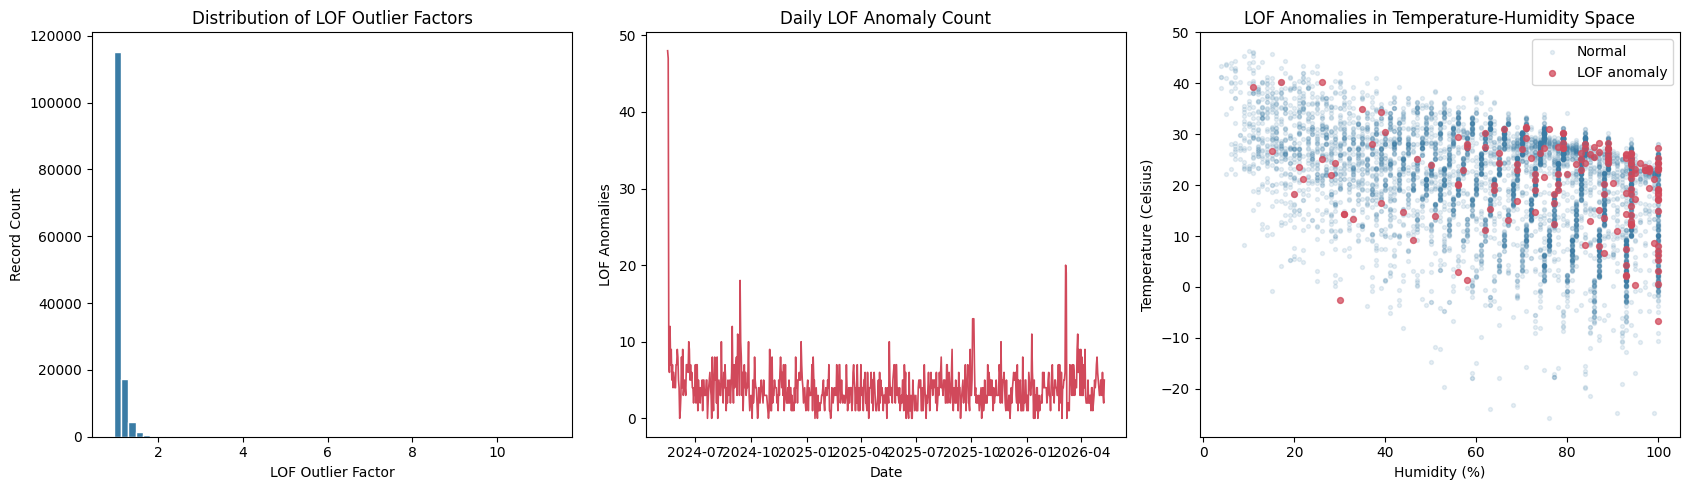

In [128]:
lof_daily = (
    lof_frame.assign(updated_date=pd.to_datetime(lof_frame["updated_date"]))
    .groupby("updated_date")
    .agg(
        lof_anomalies=("lof_anomaly", "sum"),
        avg_lof_outlier_factor=("lof_outlier_factor", "mean"),
        observations=(TARGET_COLUMN, "size"),
    )
    .reset_index()
)
lof_daily["lof_anomaly_rate"] = lof_daily["lof_anomalies"] / lof_daily["observations"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].hist(lof_frame["lof_outlier_factor"].dropna(), bins=60, color="#3A7CA5", edgecolor="white")
axes[0].set_title("Distribution of LOF Outlier Factors")
axes[0].set_xlabel("LOF Outlier Factor")
axes[0].set_ylabel("Record Count")

axes[1].plot(lof_daily["updated_date"], lof_daily["lof_anomalies"], color="#D1495B", linewidth=1.2)
axes[1].set_title("Daily LOF Anomaly Count")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("LOF Anomalies")

lof_plot_sample = lof_frame.sample(min(8_000, len(lof_frame)), random_state=RANDOM_STATE)
normal_points = lof_plot_sample.loc[~lof_plot_sample["lof_anomaly"]]
anomaly_points = lof_plot_sample.loc[lof_plot_sample["lof_anomaly"]]
axes[2].scatter(normal_points["humidity"], normal_points[TARGET_COLUMN], s=8, alpha=0.12, color="#3A7CA5", label="Normal")
axes[2].scatter(anomaly_points["humidity"], anomaly_points[TARGET_COLUMN], s=18, alpha=0.75, color="#D1495B", label="LOF anomaly")
axes[2].set_title("LOF Anomalies in Temperature-Humidity Space")
axes[2].set_xlabel("Humidity (%)")
axes[2].set_ylabel("Temperature (Celsius)")
axes[2].legend()

plt.tight_layout()
plt.show()

## Outlier Handling Before Modeling

Two modeling copies are prepared:

- `model_data_all`: all rows retained with anomaly flags available for analysis.
- `model_data_filtered`: rows removed only when flagged by both LOF and at least one strong statistical anomaly signal.

Both versions are compared during model validation so filtering is evaluated empirically.

In [129]:
statistical_anomaly_columns = [
    "temperature_location_z_anomaly",
    "temperature_celsius_iqr_anomaly",
    "precip_mm_iqr_anomaly",
    "pressure_mb_iqr_anomaly",
    "air_quality_PM2.5_iqr_anomaly",
    "air_quality_PM10_iqr_anomaly",
]

combined_anomaly_frame = lof_frame.copy()
combined_anomaly_frame["statistical_anomaly_count"] = combined_anomaly_frame[statistical_anomaly_columns].sum(axis=1)
combined_anomaly_frame["any_statistical_anomaly"] = combined_anomaly_frame["statistical_anomaly_count"] > 0
combined_anomaly_frame["strong_training_outlier"] = (
    combined_anomaly_frame["lof_anomaly"]
    & combined_anomaly_frame["any_statistical_anomaly"]
)

model_data_all = combined_anomaly_frame.copy()
model_data_filtered = combined_anomaly_frame.loc[~combined_anomaly_frame["strong_training_outlier"]].copy()

outlier_treatment_summary = pd.DataFrame({
    "dataset": ["model_data_all", "model_data_filtered"],
    "rows": [len(model_data_all), len(model_data_filtered)],
    "rows_removed": [0, len(model_data_all) - len(model_data_filtered)],
    "percent_removed": [0.0, (len(model_data_all) - len(model_data_filtered)) / len(model_data_all) * 100],
    "purpose": [
        "Primary training candidate with anomaly flags retained",
        "Conservative filtered candidate for validation comparison",
    ],
})

display(outlier_treatment_summary)

display(
    combined_anomaly_frame.loc[combined_anomaly_frame["strong_training_outlier"], [
        "country",
        "location_name",
        TIME_COLUMN,
        TARGET_COLUMN,
        "lof_outlier_factor",
        "statistical_anomaly_count",
        "temperature_location_zscore",
        "precip_mm",
        "pressure_mb",
        "air_quality_PM2.5",
        "condition_text_standardized",
    ]]
    .sort_values(["statistical_anomaly_count", "lof_outlier_factor"], ascending=False)
    .head(25)
)

,dataset,rows,rows_removed,percent_removed,purpose
0,model_data_all,140337,0,0.000,Primary training candidate with anomaly flags ...
1,model_data_filtered,138071,2266,1.615,Conservative filtered candidate for validation...


,country,location_name,last_updated,temperature_celsius,lof_outlier_factor,statistical_anomaly_count,temperature_location_zscore,precip_mm,pressure_mb,air_quality_PM2.5,condition_text_standardized
97458,Philippines,Manila,2024-10-23 17:15:00,27.100,1.592,4,-1.249,0.390,995.000,59.200,Overcast
137474,Vietnam,Hanoi,2024-07-23 19:30:00,24.700,1.424,4,-0.497,0.740,995.000,196.500,Light Drizzle
42816,Fiji Islands,Suva,2026-04-24 18:30:00,79.300,6.492,3,18.067,0.990,"1,013.000",4.250,Partly Cloudy
79018,Mauritania,Nouakchott,2025-07-15 08:45:00,23.200,3.401,3,-0.048,0.780,"1,014.000",69.560,Light Rain
27540,China,Beijing,2024-07-19 20:30:00,27.100,3.160,3,0.860,0.740,"1,000.000",169.100,Thundery Outbreaks Possible
106567,Saudi Arabia,Riyadh,2025-12-18 10:00:00,9.100,2.897,3,-2.090,0.300,"1,019.000",92.150,Moderate Rain
66130,Kuwait,Kuwait City,2025-01-07 13:45:00,18.300,2.749,3,-1.156,0.630,"1,017.000",103.230,Partly Cloudy
93402,Pakistan,Islamabad,2025-07-08 13:45:00,26.300,2.722,3,-0.258,9.880,"1,000.000",85.285,Heavy Rain
59256,Iraq,Baghdad,2025-12-08 10:15:00,19.300,2.636,3,-0.781,1.880,"1,017.000",59.350,Overcast
7213,Azerbaijan,Baku,2024-05-26 18:00:00,23.000,2.613,3,0.487,0.200,"1,013.000",188.000,Mist


## EDA Coverage Notes

All original columns are represented directly or through cleaner derived versions. Duplicate units are retained in association tables for transparency, but model features keep one unit per measurement to avoid redundancy.

# 2. Preprocessing and Forecast Modeling

The modeling workflow uses a strict future holdout split. Feature engineering, column selection, encoding, scaling, outlier filtering, and model evaluation are structured to avoid validation leakage.

## Modeling Design

The model predicts `temperature_celsius` using information available before or at the forecast timestamp:

- static geography: country, city, timezone, latitude, longitude
- known calendar and astronomy fields
- lagged weather and air-quality measurements from prior observations within the same location
- previous categorical weather state, such as prior condition and prior wind direction

Direct temperature duplicates and same-row weather measurements are excluded from the feature set.

In [130]:
import time

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

VALIDATION_FRACTION_BY_DATE = 0.20
MODEL_RANDOM_STATE = RANDOM_STATE

## Forecasting Frame and Lag Features

Lag and rolling features are created by location. Training rows use prior observations from the training period. Validation lag features are rebuilt from training history only, creating a strict future holdout evaluation.

In [131]:
forecasting_frame = eda_weather.sort_values(["location_key", TIME_COLUMN]).copy()

# Elapsed time features are known from the timestamp and do not use the target.
forecasting_frame["days_since_dataset_start"] = (
    forecasting_frame[TIME_COLUMN] - forecasting_frame[TIME_COLUMN].min()
).dt.total_seconds() / (24 * 60 * 60)
forecasting_frame["hours_since_previous_observation"] = (
    forecasting_frame.groupby("location_key")[TIME_COLUMN].diff().dt.total_seconds() / (60 * 60)
)

# Lag numeric measurements that would have been known from prior observations.
LAG_NUMERIC_BASE_FEATURES = [
    TARGET_COLUMN,
    "humidity",
    "pressure_mb",
    "precip_mm",
    "wind_mph",
    "gust_mph",
    "cloud",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Ozone",
]

LAG_STEPS_BY_FEATURE = {
    TARGET_COLUMN: [1, 2, 3, 7, 14],
    "humidity": [1, 2, 7],
    "pressure_mb": [1, 2, 7],
    "precip_mm": [1, 2, 7],
    "wind_mph": [1, 2, 7],
    "gust_mph": [1, 2, 7],
    "cloud": [1, 2, 7],
    "visibility_km": [1, 2, 7],
    "uv_index": [1, 2, 7],
    "air_quality_PM2.5": [1, 2, 7],
    "air_quality_PM10": [1, 2, 7],
    "air_quality_Ozone": [1, 2, 7],
}

lag_feature_columns = []
for feature, lags in LAG_STEPS_BY_FEATURE.items():
    for lag in lags:
        new_col = f"{feature}_lag_{lag}"
        forecasting_frame[new_col] = forecasting_frame.groupby("location_key")[feature].shift(lag)
        lag_feature_columns.append(new_col)

# Rolling features are shifted first, so they only use observations before the target timestamp.
rolling_specs = [
    (TARGET_COLUMN, 3, "temperature_rolling_mean_3"),
    (TARGET_COLUMN, 7, "temperature_rolling_mean_7"),
    (TARGET_COLUMN, 14, "temperature_rolling_mean_14"),
    ("precip_mm", 7, "precip_rolling_mean_7"),
    ("humidity", 7, "humidity_rolling_mean_7"),
    ("air_quality_PM2.5", 7, "pm25_rolling_mean_7"),
]

rolling_feature_columns = []
for feature, window, new_col in rolling_specs:
    forecasting_frame[new_col] = (
        forecasting_frame.groupby("location_key")[feature]
        .transform(lambda values: values.shift(1).rolling(window=window, min_periods=2).mean())
    )
    rolling_feature_columns.append(new_col)

forecasting_frame["temperature_lag_change_1_2"] = (
    forecasting_frame["temperature_celsius_lag_1"] - forecasting_frame["temperature_celsius_lag_2"]
)
forecasting_frame["temperature_lag_change_1_7"] = (
    forecasting_frame["temperature_celsius_lag_1"] - forecasting_frame["temperature_celsius_lag_7"]
)
lag_feature_columns.extend(["temperature_lag_change_1_2", "temperature_lag_change_1_7"])

# Prior categorical state. These are encoded later, using categories learned from the training period only.
forecasting_frame["condition_text_standardized_lag_1"] = forecasting_frame.groupby("location_key")["condition_text_standardized"].shift(1)
forecasting_frame["wind_direction_lag_1"] = forecasting_frame.groupby("location_key")["wind_direction"].shift(1)
forecasting_frame["moon_phase_lag_1"] = forecasting_frame.groupby("location_key")["moon_phase"].shift(1)

rows_before_lag_filter = len(forecasting_frame)
forecasting_frame = forecasting_frame.dropna(subset=[TARGET_COLUMN, "temperature_celsius_lag_1"]).copy()
rows_after_lag_filter = len(forecasting_frame)

lag_summary = pd.DataFrame({
    "metric": [
        "rows_before_lag_filter",
        "rows_after_lag_filter",
        "rows_removed_missing_first_lag",
        "numeric_lag_features",
        "rolling_features",
    ],
    "value": [
        f"{rows_before_lag_filter:,}",
        f"{rows_after_lag_filter:,}",
        f"{rows_before_lag_filter - rows_after_lag_filter:,}",
        len(lag_feature_columns),
        len(rolling_feature_columns),
    ],
})

display(lag_summary)
display(forecasting_frame[["country", "location_name", TIME_COLUMN, TARGET_COLUMN, "temperature_celsius_lag_1", "temperature_rolling_mean_7", "condition_text_standardized_lag_1"]].head(10))

,metric,value
0,rows_before_lag_filter,"140,337"
1,rows_after_lag_filter,"140,067"
2,rows_removed_missing_first_lag,270
3,numeric_lag_features,40
4,rolling_features,6


,country,location_name,last_updated,temperature_celsius,temperature_celsius_lag_1,temperature_rolling_mean_7,condition_text_standardized_lag_1
1,Afghanistan,Kabul,2024-05-16 18:30:00,22.000,26.600,NaN,Partly Cloudy
2,Afghanistan,Kabul,2024-05-17 20:30:00,15.000,22.000,24.300,Patchy Rain Nearby
3,Afghanistan,Kabul,2024-05-18 19:00:00,19.500,15.000,21.200,Patchy Rain Nearby
4,Afghanistan,Kabul,2024-05-19 18:30:00,16.900,19.500,20.775,Clear
5,Afghanistan,Kabul,2024-05-20 19:00:00,14.100,16.900,20.000,Patchy Rain Nearby
6,Afghanistan,Kabul,2024-05-21 19:15:00,21.800,14.100,19.017,Patchy Rain Nearby
7,Afghanistan,Kabul,2024-05-22 18:45:00,19.900,21.800,19.414,Clear
8,Afghanistan,Kabul,2024-05-23 18:30:00,23.800,19.900,18.457,Sunny
9,Afghanistan,Kabul,2024-05-24 19:00:00,18.500,23.800,18.714,Partly Cloudy
10,Afghanistan,Kabul,2024-05-25 18:30:00,22.500,18.500,19.214,Patchy Rain Nearby


## Strict Future Holdout Split

The split is made by date, not randomly. Random splitting would mix future and past rows from the same locations, which is not appropriate for forecasting.

To avoid leakage from the validation period, validation lag features are rebuilt from training history only. The validation period remains later in time and is not filtered, because future production data may contain real extremes the model must handle.

In [132]:
forecasting_frame["model_date"] = pd.to_datetime(forecasting_frame["updated_date"])
unique_model_dates = np.array(sorted(forecasting_frame["model_date"].dropna().unique()))
validation_start_index = int(len(unique_model_dates) * (1 - VALIDATION_FRACTION_BY_DATE))
validation_start_date = pd.Timestamp(unique_model_dates[validation_start_index])

train_raw_all = forecasting_frame.loc[forecasting_frame["model_date"] < validation_start_date].copy()
valid_raw = forecasting_frame.loc[forecasting_frame["model_date"] >= validation_start_date].copy()

train_raw_all = train_raw_all.sort_values([TIME_COLUMN, "location_key"]).reset_index(drop=True)
valid_raw = valid_raw.sort_values([TIME_COLUMN, "location_key"]).reset_index(drop=True)


def rebuild_validation_lags_from_training_history(train_frame, validation_frame):
    strict_validation = validation_frame.copy()

    # Start from a blank future-holdout feature state. This prevents validation-only
    # locations from keeping lag values that were computed from earlier validation rows.
    numeric_columns_to_rebuild = ["hours_since_previous_observation"] + lag_feature_columns + rolling_feature_columns
    categorical_columns_to_rebuild = [
        "condition_text_standardized_lag_1",
        "wind_direction_lag_1",
        "moon_phase_lag_1",
    ]
    for rebuild_col in numeric_columns_to_rebuild:
        if rebuild_col in strict_validation.columns:
            strict_validation[rebuild_col] = np.nan
    for rebuild_col in categorical_columns_to_rebuild:
        if rebuild_col in strict_validation.columns:
            strict_validation[rebuild_col] = pd.Series(pd.NA, index=strict_validation.index, dtype="object")

    for location_key, history in train_frame.groupby("location_key", sort=False):
        history = history.sort_values(TIME_COLUMN)
        valid_mask = strict_validation["location_key"].eq(location_key)
        if not valid_mask.any() or history.empty:
            continue

        last_training_timestamp = history[TIME_COLUMN].iloc[-1]
        strict_validation.loc[valid_mask, "hours_since_previous_observation"] = (
            strict_validation.loc[valid_mask, TIME_COLUMN] - last_training_timestamp
        ).dt.total_seconds() / (60 * 60)

        for feature, lags in LAG_STEPS_BY_FEATURE.items():
            history_values = history[feature].dropna().to_numpy()
            for lag in lags:
                lag_col = f"{feature}_lag_{lag}"
                strict_validation.loc[valid_mask, lag_col] = history_values[-lag] if len(history_values) >= lag else np.nan

        for feature, window, rolling_col in rolling_specs:
            history_values = history[feature].dropna().tail(window)
            strict_validation.loc[valid_mask, rolling_col] = history_values.mean() if len(history_values) >= 2 else np.nan

        strict_validation.loc[valid_mask, "condition_text_standardized_lag_1"] = history["condition_text_standardized"].dropna().iloc[-1]
        strict_validation.loc[valid_mask, "wind_direction_lag_1"] = history["wind_direction"].dropna().iloc[-1]
        strict_validation.loc[valid_mask, "moon_phase_lag_1"] = history["moon_phase"].dropna().iloc[-1]

    strict_validation["temperature_lag_change_1_2"] = (
        strict_validation["temperature_celsius_lag_1"] - strict_validation["temperature_celsius_lag_2"]
    )
    strict_validation["temperature_lag_change_1_7"] = (
        strict_validation["temperature_celsius_lag_1"] - strict_validation["temperature_celsius_lag_7"]
    )

    return strict_validation


valid_raw = rebuild_validation_lags_from_training_history(train_raw_all, valid_raw)

split_summary = pd.DataFrame({
    "split": ["train", "validation"],
    "rows": [len(train_raw_all), len(valid_raw)],
    "first_timestamp": [train_raw_all[TIME_COLUMN].min(), valid_raw[TIME_COLUMN].min()],
    "last_timestamp": [train_raw_all[TIME_COLUMN].max(), valid_raw[TIME_COLUMN].max()],
    "locations": [train_raw_all["location_key"].nunique(), valid_raw["location_key"].nunique()],
    "avg_target": [train_raw_all[TARGET_COLUMN].mean(), valid_raw[TARGET_COLUMN].mean()],
})

display(split_summary)
print(f"Validation starts on: {validation_start_date.date()}")
print("Validation lag features rebuilt from training history only.")

,split,rows,first_timestamp,last_timestamp,locations,avg_target
0,train,112182,2024-05-16 07:15:00,2025-12-15 23:15:00,223,22.299
1,validation,27885,2025-12-16 01:15:00,2026-05-09 19:30:00,202,16.974


Validation starts on: 2025-12-16
Validation lag features rebuilt from training history only.


## Column Removal and Feature Selection

The model uses an explicit keep-list to make feature inclusion clear.

Excluded feature groups:

- **Target/direct duplicates**: Fahrenheit temperature and feels-like fields.
- **Duplicate units**: alternate units for wind, pressure, precipitation, and visibility.
- **Raw timestamps/strings**: replaced with parsed calendar or numeric minute fields.
- **Same-row weather measurements**: replaced with lagged versions.
- **EDA-only anomaly fields**: used for analysis and filtering, not as predictors.

Rows with missing selected model features from lag/rolling construction are filtered before model fitting.

In [133]:
STATIC_NUMERIC_FEATURES = [
    "latitude",
    "longitude",
]

CALENDAR_NUMERIC_FEATURES = [
    "days_since_dataset_start",
    "hours_since_previous_observation",
    "updated_year",
    "updated_month",
    "updated_day_of_week",
    "updated_day_of_year",
    "updated_week",
    "updated_quarter",
    "updated_hour",
    "updated_is_weekend",
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "hour_sin",
    "hour_cos",
]

ASTRONOMY_NUMERIC_FEATURES = [
    "sunrise_minutes",
    "sunset_minutes",
    "daylight_minutes",
    "moon_illumination",
]

NUMERIC_MODEL_FEATURES = [
    feature for feature in (
        STATIC_NUMERIC_FEATURES
        + CALENDAR_NUMERIC_FEATURES
        + ASTRONOMY_NUMERIC_FEATURES
        + lag_feature_columns
        + rolling_feature_columns
    )
    if feature in forecasting_frame.columns
]

CATEGORICAL_MODEL_FEATURES = [
    "country",
    "location_name",
    "timezone",
    "moon_phase",
    "condition_text_standardized_lag_1",
    "wind_direction_lag_1",
    "moon_phase_lag_1",
]
CATEGORICAL_MODEL_FEATURES = [feature for feature in CATEGORICAL_MODEL_FEATURES if feature in forecasting_frame.columns]

MODEL_FEATURES = NUMERIC_MODEL_FEATURES + CATEGORICAL_MODEL_FEATURES

removed_feature_rows = [
    {
        "removed_or_excluded_feature_group": "target/direct temperature duplicates",
        "features": [TARGET_COLUMN, "temperature_fahrenheit", "feels_like_celsius", "feels_like_fahrenheit"],
        "reason": "Target or target-adjacent measurements; unsafe as predictors of Celsius temperature.",
    },
    {
        "removed_or_excluded_feature_group": "duplicate unit columns",
        "features": ["wind_kph", "gust_kph", "pressure_in", "precip_in", "visibility_miles"],
        "reason": "Duplicate measurements already represented by mph, mb, mm, or km features/lags.",
    },
    {
        "removed_or_excluded_feature_group": "raw timestamp fields",
        "features": ["last_updated_epoch", "last_updated", "last_updated_raw", "updated_date", "model_date"],
        "reason": "Replaced with parsed calendar, cyclical, and elapsed-time fields.",
    },
    {
        "removed_or_excluded_feature_group": "same-row weather measurements",
        "features": [
            "condition_text", "condition_text_standardized", "wind_mph", "wind_degree", "wind_direction",
            "pressure_mb", "precip_mm", "humidity", "cloud", "visibility_km", "uv_index",
            "gust_mph", "air_quality_PM2.5", "air_quality_PM10", "air_quality_Ozone",
        ],
        "reason": "Current weather values are replaced with prior-observation lags to avoid forecasting leakage.",
    },
    {
        "removed_or_excluded_feature_group": "raw astronomy clock strings",
        "features": ["sunrise", "sunset", "moonrise", "moonset"],
        "reason": "Replaced with numeric minutes and daylight duration.",
    },
    {
        "removed_or_excluded_feature_group": "EDA anomaly flags and scores",
        "features": ["lof_score", "lof_outlier_factor", "lof_anomaly", "temperature_location_zscore"],
        "reason": "Some are target-derived and used only for training-row filtering, not as model inputs.",
    },
]

feature_selection_summary = pd.DataFrame({
    "feature_type": ["numeric", "categorical", "total"],
    "feature_count": [len(NUMERIC_MODEL_FEATURES), len(CATEGORICAL_MODEL_FEATURES), len(MODEL_FEATURES)],
})

removed_feature_summary = pd.DataFrame(removed_feature_rows)

rows_before_feature_missing_filter = {
    "train": len(train_raw_all),
    "validation": len(valid_raw),
}
train_raw_all = train_raw_all.dropna(subset=MODEL_FEATURES + [TARGET_COLUMN]).copy().reset_index(drop=True)
valid_raw = valid_raw.dropna(subset=MODEL_FEATURES + [TARGET_COLUMN]).copy().reset_index(drop=True)
rows_after_feature_missing_filter = {
    "train": len(train_raw_all),
    "validation": len(valid_raw),
}

feature_missing_filter_summary = pd.DataFrame({
    "split": ["train", "validation"],
    "rows_before": [rows_before_feature_missing_filter["train"], rows_before_feature_missing_filter["validation"]],
    "rows_after": [rows_after_feature_missing_filter["train"], rows_after_feature_missing_filter["validation"]],
    "rows_removed_for_engineered_missingness": [
        rows_before_feature_missing_filter["train"] - rows_after_feature_missing_filter["train"],
        rows_before_feature_missing_filter["validation"] - rows_after_feature_missing_filter["validation"],
    ],
})

display(feature_selection_summary)
display(pd.DataFrame({"numeric_features": NUMERIC_MODEL_FEATURES}))
display(pd.DataFrame({"categorical_features": CATEGORICAL_MODEL_FEATURES}))
display(removed_feature_summary)
display(feature_missing_filter_summary)

,feature_type,feature_count
0,numeric,68
1,categorical,7
2,total,75


,numeric_features
0,latitude
1,longitude
2,days_since_dataset_start
3,hours_since_previous_observation
4,updated_year
5,updated_month
6,updated_day_of_week
7,updated_day_of_year
8,updated_week
9,updated_quarter


,categorical_features
0,country
1,location_name
2,timezone
3,moon_phase
4,condition_text_standardized_lag_1
5,wind_direction_lag_1
6,moon_phase_lag_1


,removed_or_excluded_feature_group,features,reason
0,target/direct temperature duplicates,"[temperature_celsius, temperature_fahrenheit, ...",Target or target-adjacent measurements; unsafe...
1,duplicate unit columns,"[wind_kph, gust_kph, pressure_in, precip_in, v...",Duplicate measurements already represented by ...
2,raw timestamp fields,"[last_updated_epoch, last_updated, last_update...","Replaced with parsed calendar, cyclical, and e..."
3,same-row weather measurements,"[condition_text, condition_text_standardized, ...",Current weather values are replaced with prior...
4,raw astronomy clock strings,"[sunrise, sunset, moonrise, moonset]",Replaced with numeric minutes and daylight dur...
5,EDA anomaly flags and scores,"[lof_score, lof_outlier_factor, lof_anomaly, t...",Some are target-derived and used only for trai...


,split,rows_before,rows_after,rows_removed_for_engineered_missingness
0,train,112182,109299,2883
1,validation,27885,27667,218


## Encoding and Scaling

The raw dataset has no missing values. After lag and rolling feature construction, rows with missing selected model features are dropped explicitly. Numeric features are standardized, and categorical features are one-hot encoded with infrequent-category grouping.

In [134]:
def make_preprocessor():
    numeric_pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=50,
            max_categories=40,
            sparse_output=False,
            dtype=np.float32,
        )),
    ])

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_MODEL_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_MODEL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


preprocessor_audit = make_preprocessor()
X_train_audit = preprocessor_audit.fit_transform(train_raw_all[MODEL_FEATURES])
X_valid_audit = preprocessor_audit.transform(valid_raw[MODEL_FEATURES])
encoded_feature_names = preprocessor_audit.get_feature_names_out()

preprocessing_audit = pd.DataFrame({
    "matrix": ["train_raw_all", "valid_raw"],
    "rows": [X_train_audit.shape[0], X_valid_audit.shape[0]],
    "encoded_columns": [X_train_audit.shape[1], X_valid_audit.shape[1]],
    "fit_rule": ["fit_transform on training period", "transform only using training-fitted preprocessor"],
})

display(preprocessing_audit)
display(pd.DataFrame({"encoded_feature_name": encoded_feature_names}).head(40))

del X_train_audit, X_valid_audit

,matrix,rows,encoded_columns,fit_rule
0,train_raw_all,109299,245,fit_transform on training period
1,valid_raw,27667,245,transform only using training-fitted preprocessor


,encoded_feature_name
0,latitude
1,longitude
2,days_since_dataset_start
3,hours_since_previous_observation
4,updated_year
5,updated_month
6,updated_day_of_week
7,updated_day_of_year
8,updated_week
9,updated_quarter


## Training-Only Outlier Filtering

The EDA anomaly flags were computed for analysis. For modeling, outlier removal is recomputed on the training period only. The validation period is not used to set thresholds, fit LOF, or decide which training rows to remove.

In [135]:
TRAIN_OUTLIER_FEATURES = [
    TARGET_COLUMN,
    "precip_mm",
    "wind_mph",
    "gust_mph",
    "pressure_mb",
    "humidity",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Ozone",
]

TRAIN_LOF_FEATURES = [
    TARGET_COLUMN,
    "humidity",
    "pressure_mb",
    "wind_mph",
    "gust_mph",
    "cloud",
    "visibility_km",
    "uv_index",
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "hour_sin",
    "hour_cos",
    "precip_mm",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Ozone",
]


def compute_training_outlier_flags(train_frame, contamination=LOF_CONTAMINATION, n_neighbors=LOF_NEIGHBORS, min_group_size=MIN_LOF_GROUP_SIZE):
    flags = pd.DataFrame(index=train_frame.index)

    for feature in TRAIN_OUTLIER_FEATURES:
        lower, upper = iqr_bounds(train_frame[feature], multiplier=1.5)
        flags[f"{feature}_train_iqr_anomaly"] = train_frame[feature].lt(lower) | train_frame[feature].gt(upper)

    location_temperature = train_frame.groupby("location_key")[TARGET_COLUMN]
    location_mean = location_temperature.transform("mean")
    location_std = location_temperature.transform("std").replace(0, np.nan)
    flags["temperature_train_location_zscore"] = (train_frame[TARGET_COLUMN] - location_mean) / location_std
    flags["temperature_train_location_z_anomaly"] = flags["temperature_train_location_zscore"].abs() >= 3

    lof_scores = pd.Series(np.nan, index=train_frame.index, dtype="float64")
    lof_anomalies = pd.Series(False, index=train_frame.index, dtype="bool")

    for location_key, group in train_frame.groupby("location_key", sort=False):
        if len(group) < min_group_size:
            continue

        group_features = group[TRAIN_LOF_FEATURES].copy()
        for skewed_feature in ["precip_mm", "air_quality_PM2.5", "air_quality_PM10", "air_quality_Ozone"]:
            if skewed_feature in group_features.columns:
                group_features[skewed_feature] = np.log1p(pd.to_numeric(group_features[skewed_feature], errors="coerce").clip(lower=0))

        scaled_features = StandardScaler().fit_transform(group_features)
        effective_neighbors = min(n_neighbors, len(group) - 1)

        lof = LocalOutlierFactor(n_neighbors=effective_neighbors, contamination=contamination)
        labels = lof.fit_predict(scaled_features)
        lof_scores.loc[group.index] = -lof.negative_outlier_factor_
        lof_anomalies.loc[group.index] = labels == -1

    flags["train_lof_outlier_factor"] = lof_scores
    flags["train_lof_anomaly"] = lof_anomalies

    statistical_cols = [
        "temperature_celsius_train_iqr_anomaly",
        "precip_mm_train_iqr_anomaly",
        "pressure_mb_train_iqr_anomaly",
        "air_quality_PM2.5_train_iqr_anomaly",
        "air_quality_PM10_train_iqr_anomaly",
        "temperature_train_location_z_anomaly",
    ]
    flags["train_statistical_anomaly_count"] = flags[statistical_cols].sum(axis=1)
    flags["strong_training_outlier"] = flags["train_lof_anomaly"] & flags["train_statistical_anomaly_count"].gt(0)

    return flags


train_outlier_flags = compute_training_outlier_flags(train_raw_all)
train_raw_filtered = train_raw_all.loc[~train_outlier_flags["strong_training_outlier"]].copy()

training_versions_summary = pd.DataFrame({
    "training_version": ["all_training_rows", "filtered_training_rows"],
    "rows": [len(train_raw_all), len(train_raw_filtered)],
    "rows_removed": [0, len(train_raw_all) - len(train_raw_filtered)],
    "percent_removed": [0.0, (len(train_raw_all) - len(train_raw_filtered)) / len(train_raw_all) * 100],
    "rule": [
        "No training rows removed",
        "Remove rows flagged by train-only LOF and at least one train-only statistical anomaly",
    ],
})

display(training_versions_summary)
display(train_outlier_flags.loc[train_outlier_flags["strong_training_outlier"]].sort_values(["train_statistical_anomaly_count", "train_lof_outlier_factor"], ascending=False).head(20))

,training_version,rows,rows_removed,percent_removed,rule
0,all_training_rows,109299,0,0.000,No training rows removed
1,filtered_training_rows,107459,1840,1.683,Remove rows flagged by train-only LOF and at l...


,temperature_celsius_train_iqr_anomaly,precip_mm_train_iqr_anomaly,wind_mph_train_iqr_anomaly,gust_mph_train_iqr_anomaly,pressure_mb_train_iqr_anomaly,humidity_train_iqr_anomaly,air_quality_PM2.5_train_iqr_anomaly,air_quality_PM10_train_iqr_anomaly,air_quality_Ozone_train_iqr_anomaly,temperature_train_location_zscore,temperature_train_location_z_anomaly,train_lof_outlier_factor,train_lof_anomaly,train_statistical_anomaly_count,strong_training_outlier
92504,False,True,False,False,False,False,True,True,False,-3.042,True,1.481,True,4,True
10103,False,True,False,False,True,False,True,True,False,-0.599,False,1.420,True,4,True
42712,False,True,False,False,False,False,True,True,False,-1.530,False,4.910,True,3,True
49928,False,True,False,False,False,False,True,True,False,-1.514,False,4.131,True,3,True
34742,False,True,False,False,False,False,True,True,False,-1.429,False,3.448,True,3,True
79440,False,True,False,False,False,False,True,True,False,-0.370,False,3.318,True,3,True
9739,False,True,True,True,False,False,True,True,False,0.722,False,3.098,True,3,True
78192,False,True,False,False,False,False,True,True,False,-0.451,False,2.931,True,3,True
57659,False,True,False,False,False,False,True,True,False,-1.244,False,2.597,True,3,True
6749,True,False,False,False,True,False,False,False,False,-5.251,True,2.519,True,3,True


## Regression Models and Ensembles

The model set includes:

- Ridge Regression as a linear baseline
- Random Forest Regressor as a bagged nonlinear model
- HistGradientBoosting Regressor as a boosted-tree model
- Soft averaging ensemble across the three base models
- Holdout stacking ensemble with a Ridge meta-model

Each model is trained on both all training rows and the conservative filtered training set. Forecast accuracy is reported as the percentage of predictions within ±2°C, ±3°C, and ±5°C of the actual temperature.

Holdout stacking is time-ordered: the meta-model is trained on a later slice of the training period, and validation predictions come from base models refit on the full training period.

In [136]:
def make_regression_model_specs():
    return {
        "Ridge Regression": Pipeline(steps=[
            ("preprocessor", make_preprocessor()),
            ("model", Ridge(alpha=3.0)),
        ]),
        "Random Forest": Pipeline(steps=[
            ("preprocessor", make_preprocessor()),
            ("model", RandomForestRegressor(
                n_estimators=80,
                max_depth=16,
                min_samples_leaf=8,
                max_features="sqrt",
                n_jobs=-1,
                random_state=MODEL_RANDOM_STATE,
            )),
        ]),
        "HistGradientBoosting": Pipeline(steps=[
            ("preprocessor", make_preprocessor()),
            ("model", HistGradientBoostingRegressor(
                learning_rate=0.07,
                max_iter=120,
                max_leaf_nodes=31,
                min_samples_leaf=40,
                l2_regularization=0.05,
                random_state=MODEL_RANDOM_STATE,
            )),
        ]),
    }


def evaluate_regression_predictions(model_name, training_version, y_true, predictions, fit_seconds=None):
    predictions = np.asarray(predictions, dtype="float64")
    errors = np.asarray(y_true, dtype="float64") - predictions
    absolute_errors = np.abs(errors)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    return {
        "training_version": training_version,
        "model": model_name,
        "mae": mean_absolute_error(y_true, predictions),
        "rmse": rmse,
        "r2": r2_score(y_true, predictions),
        "accuracy_within_2c": (absolute_errors <= 2).mean(),
        "accuracy_within_3c": (absolute_errors <= 3).mean(),
        "accuracy_within_5c": (absolute_errors <= 5).mean(),
        "prediction_mean": predictions.mean(),
        "prediction_std": predictions.std(),
        "fit_seconds": fit_seconds,
    }


VALIDATION_X = valid_raw[MODEL_FEATURES]
VALIDATION_Y = valid_raw[TARGET_COLUMN]

baseline_predictions = VALIDATION_X["temperature_celsius_lag_1"].to_numpy()
baseline_result = evaluate_regression_predictions(
    "Previous Observation Baseline",
    "no_fit_baseline",
    VALIDATION_Y,
    baseline_predictions,
    fit_seconds=0.0,
)

display(pd.DataFrame([baseline_result]))

,training_version,model,mae,rmse,r2,accuracy_within_2c,accuracy_within_3c,accuracy_within_5c,prediction_mean,prediction_std,fit_seconds
0,no_fit_baseline,Previous Observation Baseline,3.741,5.542,0.739,0.457,0.581,0.750,16.225,10.593,0.000


In [137]:
def make_time_ordered_meta_split(train_frame, validation_fraction=0.20):
    unique_dates = np.array(sorted(train_frame["model_date"].dropna().unique()))
    split_index = int(len(unique_dates) * (1 - validation_fraction))
    meta_start_date = pd.Timestamp(unique_dates[split_index])
    base_fit = train_frame.loc[train_frame["model_date"] < meta_start_date].copy()
    meta_fit = train_frame.loc[train_frame["model_date"] >= meta_start_date].copy()
    return base_fit, meta_fit, meta_start_date


def fit_holdout_stacking(train_frame, validation_predictions, training_version):
    base_fit_frame, meta_fit_frame, meta_start_date = make_time_ordered_meta_split(train_frame)
    meta_predictions = {}

    for model_name, estimator in make_regression_model_specs().items():
        inner_model = clone(estimator)
        inner_model.fit(base_fit_frame[MODEL_FEATURES], base_fit_frame[TARGET_COLUMN])
        meta_predictions[model_name] = inner_model.predict(meta_fit_frame[MODEL_FEATURES])

    meta_X = pd.DataFrame(meta_predictions, index=meta_fit_frame.index)
    meta_y = meta_fit_frame[TARGET_COLUMN]
    meta_model = Ridge(alpha=1.0)
    meta_model.fit(meta_X, meta_y)

    valid_meta_X = pd.DataFrame(validation_predictions)
    stacking_predictions = meta_model.predict(valid_meta_X)

    stack_notes = {
        "training_version": training_version,
        "meta_start_date": meta_start_date,
        "base_fit_rows": len(base_fit_frame),
        "meta_fit_rows": len(meta_fit_frame),
        "meta_coefficients": dict(zip(meta_X.columns, meta_model.coef_)),
        "meta_intercept": meta_model.intercept_,
    }
    return stacking_predictions, stack_notes


training_sets = {
    "all_training_rows": train_raw_all,
    "filtered_training_rows": train_raw_filtered,
}

model_results = [baseline_result]
fitted_models = {}
validation_predictions_by_training_version = {}
stacking_notes = []

for training_version, train_frame in training_sets.items():
    print(f"Training models on {training_version}: {len(train_frame):,} rows")
    X_train = train_frame[MODEL_FEATURES]
    y_train = train_frame[TARGET_COLUMN]

    base_validation_predictions = {}
    fitted_models[training_version] = {}

    for model_name, estimator in make_regression_model_specs().items():
        start_time = time.time()
        model = clone(estimator)
        model.fit(X_train, y_train)
        predictions = model.predict(VALIDATION_X)
        fit_seconds = round(time.time() - start_time, 1)

        fitted_models[training_version][model_name] = model
        base_validation_predictions[model_name] = predictions
        model_results.append(evaluate_regression_predictions(model_name, training_version, VALIDATION_Y, predictions, fit_seconds))

    soft_average_predictions = np.column_stack(list(base_validation_predictions.values())).mean(axis=1)
    model_results.append(evaluate_regression_predictions("Soft Average Ensemble", training_version, VALIDATION_Y, soft_average_predictions, fit_seconds=0.0))

    start_time = time.time()
    stacking_predictions, stack_note = fit_holdout_stacking(train_frame, base_validation_predictions, training_version)
    stack_note["fit_seconds"] = round(time.time() - start_time, 1)
    stacking_notes.append(stack_note)
    model_results.append(evaluate_regression_predictions("Holdout Stacking Ensemble", training_version, VALIDATION_Y, stacking_predictions, stack_note["fit_seconds"]))

    base_validation_predictions["Soft Average Ensemble"] = soft_average_predictions
    base_validation_predictions["Holdout Stacking Ensemble"] = stacking_predictions
    validation_predictions_by_training_version[training_version] = base_validation_predictions

model_results_frame = pd.DataFrame(model_results).sort_values(["rmse", "mae"]).reset_index(drop=True)
stacking_notes_frame = pd.DataFrame(stacking_notes)

display(model_results_frame)
display(stacking_notes_frame)

Training models on all_training_rows: 109,299 rows
Training models on filtered_training_rows: 107,459 rows


,training_version,model,mae,rmse,r2,accuracy_within_2c,accuracy_within_3c,accuracy_within_5c,prediction_mean,prediction_std,fit_seconds
0,filtered_training_rows,Random Forest,3.057,4.464,0.831,0.504,0.641,0.810,16.932,9.607,4.900
1,all_training_rows,Random Forest,3.096,4.542,0.825,0.500,0.639,0.806,16.866,9.621,5.000
2,filtered_training_rows,Soft Average Ensemble,3.212,4.749,0.808,0.491,0.629,0.794,16.747,9.923,0.000
3,all_training_rows,Soft Average Ensemble,3.230,4.785,0.805,0.491,0.627,0.792,16.700,9.931,0.000
4,filtered_training_rows,Holdout Stacking Ensemble,3.268,4.851,0.800,0.487,0.625,0.791,16.753,10.072,11.500
5,all_training_rows,Holdout Stacking Ensemble,3.276,4.868,0.799,0.488,0.624,0.789,16.692,10.066,11.500
6,filtered_training_rows,HistGradientBoosting,3.289,4.873,0.798,0.483,0.622,0.788,16.871,10.025,8.600
7,all_training_rows,HistGradientBoosting,3.292,4.881,0.798,0.484,0.620,0.787,16.827,10.019,8.300
8,filtered_training_rows,Ridge Regression,3.359,5.029,0.785,0.481,0.615,0.782,16.437,10.187,0.800
9,all_training_rows,Ridge Regression,3.365,5.040,0.784,0.481,0.615,0.782,16.407,10.196,0.800


,training_version,meta_start_date,base_fit_rows,meta_fit_rows,meta_coefficients,meta_intercept,fit_seconds
0,all_training_rows,2025-08-25,87367,21932,"{'Ridge Regression': 0.27591280399684875, 'Ran...",-0.116,11.500
1,filtered_training_rows,2025-08-25,85904,21555,"{'Ridge Regression': 0.25206024644345076, 'Ran...",-0.116,11.500


## Feature Importance

Two complementary feature-importance techniques are used:

- **Random Forest impurity importance**: model-native importance from the selected tree model.
- **Permutation importance**: validation-based importance measuring how much MAE worsens when a feature is shuffled.

Permutation importance is emphasized because it evaluates impact on validation performance.

In [138]:
PERMUTATION_SAMPLE_SIZE = 3_000
PERMUTATION_REPEATS = 3

# The current best model is Random Forest on filtered rows. Keep this robust in case later tuning changes the winner.
rf_result_rows = model_results_frame.loc[model_results_frame["model"].eq("Random Forest")].sort_values("rmse")
if rf_result_rows.empty:
    raise RuntimeError("Random Forest results were not found. Run the modeling cells first.")

importance_training_version = rf_result_rows.iloc[0]["training_version"]
importance_model = fitted_models[importance_training_version]["Random Forest"]
importance_preprocessor = importance_model.named_steps["preprocessor"]
importance_estimator = importance_model.named_steps["model"]
encoded_importance_names = importance_preprocessor.get_feature_names_out()


def map_encoded_feature_to_model_feature(encoded_name):
    if encoded_name in NUMERIC_MODEL_FEATURES:
        return encoded_name
    for feature in CATEGORICAL_MODEL_FEATURES:
        if encoded_name == feature or encoded_name.startswith(f"{feature}_"):
            return feature
    return encoded_name


def map_model_feature_to_group(feature):
    if feature in STATIC_NUMERIC_FEATURES or feature in ["country", "location_name", "timezone"]:
        return "Location and geography"
    if feature in CALENDAR_NUMERIC_FEATURES:
        return "Calendar/time"
    if feature in ASTRONOMY_NUMERIC_FEATURES or feature in ["moon_phase", "moon_phase_lag_1"]:
        return "Sun and moon"
    if "temperature" in feature:
        return "Temperature history"
    if feature in CATEGORICAL_MODEL_FEATURES:
        return "Prior categorical state"
    if any(token in feature for token in ["humidity", "pressure", "precip", "wind", "gust", "cloud", "visibility", "uv"]):
        return "Prior weather mechanics"
    if "air_quality" in feature or "pm25" in feature:
        return "Prior air quality"
    return "Other engineered feature"


encoded_importance_frame = pd.DataFrame({
    "encoded_feature": encoded_importance_names,
    "model_feature": [map_encoded_feature_to_model_feature(name) for name in encoded_importance_names],
    "importance": importance_estimator.feature_importances_,
})

model_feature_importance_frame = (
    encoded_importance_frame.groupby("model_feature", as_index=False)
    .agg(model_importance=("importance", "sum"))
    .assign(feature_group=lambda frame: frame["model_feature"].map(map_model_feature_to_group))
    .sort_values("model_importance", ascending=False)
)

feature_group_importance_frame = (
    model_feature_importance_frame.groupby("feature_group", as_index=False)
    .agg(model_importance=("model_importance", "sum"))
    .sort_values("model_importance", ascending=False)
)

importance_sample = valid_raw.sample(
    min(PERMUTATION_SAMPLE_SIZE, len(valid_raw)),
    random_state=MODEL_RANDOM_STATE,
)
permutation_result = permutation_importance(
    importance_model,
    importance_sample[MODEL_FEATURES],
    importance_sample[TARGET_COLUMN],
    scoring="neg_mean_absolute_error",
    n_repeats=PERMUTATION_REPEATS,
    random_state=MODEL_RANDOM_STATE,
    n_jobs=1,
)

permutation_importance_frame = pd.DataFrame({
    "model_feature": MODEL_FEATURES,
    "mae_increase_from_permutation": permutation_result.importances_mean,
    "mae_increase_std": permutation_result.importances_std,
}).assign(
    feature_group=lambda frame: frame["model_feature"].map(map_model_feature_to_group)
).sort_values("mae_increase_from_permutation", ascending=False)

permutation_group_importance_frame = (
    permutation_importance_frame.groupby("feature_group", as_index=False)
    .agg(mae_increase_from_permutation=("mae_increase_from_permutation", "sum"))
    .sort_values("mae_increase_from_permutation", ascending=False)
)

print(f"Feature importance model: Random Forest trained on {importance_training_version}")
print(f"Permutation importance sample size: {len(importance_sample):,}")

display(model_feature_importance_frame.head(25))
display(feature_group_importance_frame)
display(permutation_importance_frame.head(25))
display(permutation_group_importance_frame)

Feature importance model: Random Forest trained on filtered_training_rows
Permutation importance sample size: 3,000


,model_feature,model_importance,feature_group
54,temperature_rolling_mean_7,0.122,Temperature history
52,temperature_rolling_mean_14,0.108,Temperature history
53,temperature_rolling_mean_3,0.105,Temperature history
45,temperature_celsius_lag_1,0.103,Temperature history
48,temperature_celsius_lag_3,0.087,Temperature history
47,temperature_celsius_lag_2,0.075,Temperature history
49,temperature_celsius_lag_7,0.062,Temperature history
46,temperature_celsius_lag_14,0.054,Temperature history
16,daylight_minutes,0.049,Sun and moon
43,sunrise_minutes,0.034,Sun and moon


,feature_group,model_importance
6,Temperature history,0.721
4,Prior weather mechanics,0.100
5,Sun and moon,0.096
1,Location and geography,0.035
0,Calendar/time,0.031
2,Prior air quality,0.014
3,Prior categorical state,0.002


,model_feature,mae_increase_from_permutation,mae_increase_std,feature_group
62,temperature_rolling_mean_3,0.313,0.016,Temperature history
64,temperature_rolling_mean_14,0.292,0.015,Temperature history
63,temperature_rolling_mean_7,0.290,0.016,Temperature history
22,temperature_celsius_lag_1,0.259,0.012,Temperature history
23,temperature_celsius_lag_2,0.086,0.011,Temperature history
24,temperature_celsius_lag_3,0.073,0.013,Temperature history
20,daylight_minutes,0.069,0.006,Sun and moon
0,latitude,0.049,0.001,Location and geography
25,temperature_celsius_lag_7,0.048,0.007,Temperature history
26,temperature_celsius_lag_14,0.041,0.008,Temperature history


,feature_group,mae_increase_from_permutation
6,Temperature history,1.385
5,Sun and moon,0.130
0,Calendar/time,0.107
1,Location and geography,0.059
4,Prior weather mechanics,0.027
2,Prior air quality,0.012
3,Prior categorical state,-0.002


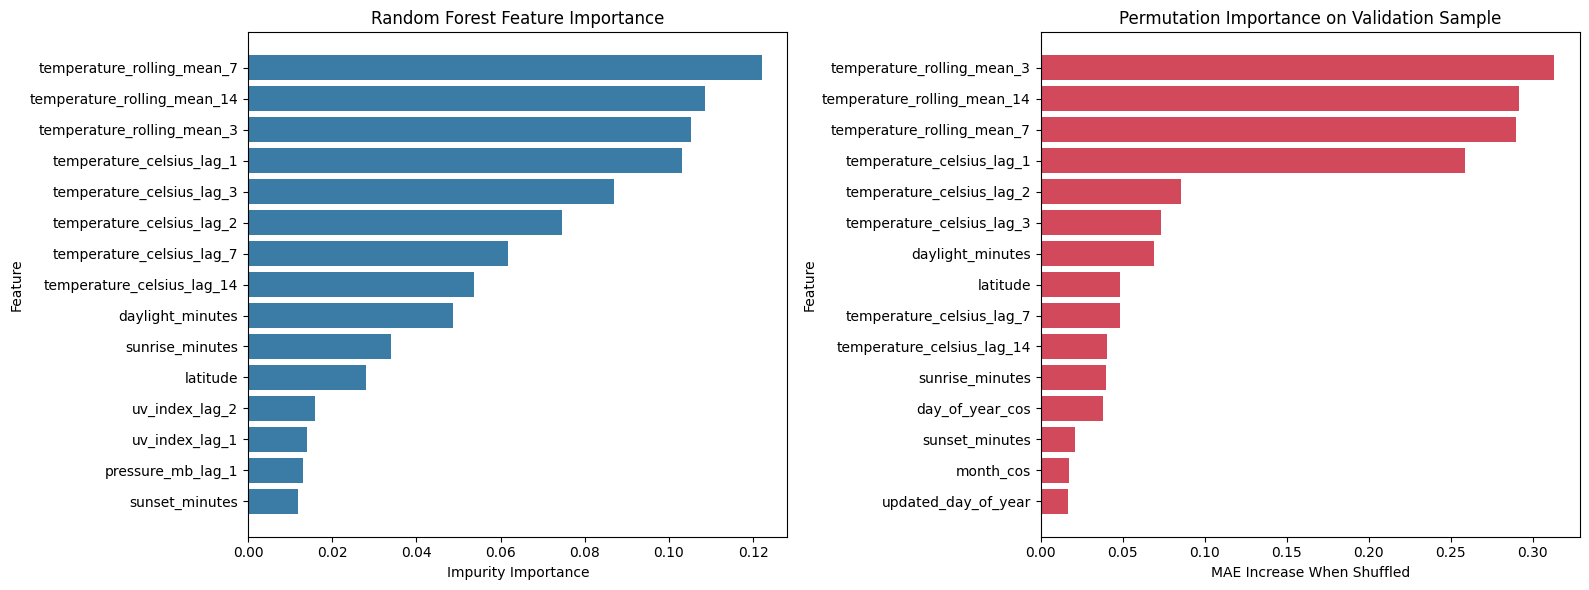

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_plot = model_feature_importance_frame.head(15).sort_values("model_importance")
axes[0].barh(model_plot["model_feature"], model_plot["model_importance"], color="#3A7CA5")
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Impurity Importance")
axes[0].set_ylabel("Feature")

permutation_plot = permutation_importance_frame.head(15).sort_values("mae_increase_from_permutation")
axes[1].barh(permutation_plot["model_feature"], permutation_plot["mae_increase_from_permutation"], color="#D1495B")
axes[1].set_title("Permutation Importance on Validation Sample")
axes[1].set_xlabel("MAE Increase When Shuffled")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

## Model Comparison Takeaways

The best model should be selected by validation RMSE/MAE on the later time window, not by training performance. If the filtered training version improves validation metrics, then the conservative outlier removal helped. If the all-rows version wins, the extreme-weather records are useful signal and should stay in the final training data.

In [140]:
best_model_row = model_results_frame.iloc[0]

best_model_summary = pd.DataFrame([{
    "selected_training_version": best_model_row["training_version"],
    "selected_model": best_model_row["model"],
    "validation_mae": best_model_row["mae"],
    "validation_rmse": best_model_row["rmse"],
    "validation_r2": best_model_row["r2"],
    "validation_accuracy_within_2c": best_model_row["accuracy_within_2c"],
    "validation_accuracy_within_3c": best_model_row["accuracy_within_3c"],
    "validation_accuracy_within_5c": best_model_row["accuracy_within_5c"],
}])

display(best_model_summary)

# Keep a compact prediction frame for later residual analysis and report charts.
selected_training_version = best_model_row["training_version"]
selected_model_name = best_model_row["model"]

if selected_model_name == "Previous Observation Baseline":
    selected_predictions = baseline_predictions
else:
    selected_predictions = validation_predictions_by_training_version[selected_training_version][selected_model_name]

validation_prediction_frame = valid_raw[["country", "location_name", TIME_COLUMN, TARGET_COLUMN, "temperature_celsius_lag_1"]].copy()
validation_prediction_frame["prediction"] = selected_predictions
validation_prediction_frame["residual"] = validation_prediction_frame[TARGET_COLUMN] - validation_prediction_frame["prediction"]
validation_prediction_frame["absolute_error"] = validation_prediction_frame["residual"].abs()

display(validation_prediction_frame.head(20))
display(validation_prediction_frame["absolute_error"].describe())

,selected_training_version,selected_model,validation_mae,validation_rmse,validation_r2,validation_accuracy_within_2c,validation_accuracy_within_3c,validation_accuracy_within_5c
0,filtered_training_rows,Random Forest,3.057,4.464,0.831,0.504,0.641,0.810


,country,location_name,last_updated,temperature_celsius,temperature_celsius_lag_1,prediction,residual,absolute_error
0,Belize,Belmopan,2025-12-16 01:15:00,18.800,20.400,20.793,-1.993,1.993
1,Costa Rica,San Jose,2025-12-16 01:15:00,19.100,21.100,20.793,-1.693,1.693
2,El Salvador,San Salvador,2025-12-16 01:15:00,28.000,23.300,24.407,3.593,3.593
3,Guatemala,Guatemala City,2025-12-16 01:15:00,16.200,17.300,17.353,-1.153,1.153
4,Honduras,Tegucigalpa,2025-12-16 01:15:00,19.100,19.200,18.907,0.193,0.193
5,Mexico,Mexico City,2025-12-16 01:15:00,11.100,13.100,13.584,-2.484,2.484
6,Nicaragua,Managua,2025-12-16 01:15:00,21.700,21.900,23.595,-1.895,1.895
7,Bahamas,Nassau,2025-12-16 02:15:00,22.400,25.400,23.492,-1.092,1.092
8,Canada,Ottawa,2025-12-16 02:15:00,-5.600,-14.800,-9.332,3.732,3.732
9,Cuba,Havana,2025-12-16 02:15:00,20.100,22.100,21.919,-1.819,1.819


count   27,667.000
mean         3.057
std          3.252
min          0.000
25%          0.857
50%          1.977
75%          4.119
max         53.736
Name: absolute_error, dtype: float64